# 08 — Explainable AI Analysis

This notebook explains the fitted multinomial Logistic Regression model without refitting it. It reproduces the 2023–2025 held-out predictions, calculates linear-model SHAP values, summarizes global and grouped contributions, examines Medium-class uncertainty, and creates local explanations for selected county-years and the six priority hidden-risk counties.

**Primary input:** `data/processed/florida_county_year_vulnerability_2011_2025.csv`  
**Upstream artifacts:** fitted model and predictions from Notebook 05, feature-group results from Notebook 06, and profile/hidden-risk outputs from Notebook 07.  
**Outputs:** explainability tables and metadata under `results/tables/shap_explainability/`, plus seven report-ready figures under `results/figures/shap_explainability/`.

SHAP values describe the fitted model's score structure and associations. They do not establish causal effects.


## 1. Setup, inputs, and artifact audit

Load the saved analytical artifacts, standardize county-year identifiers, and verify feature, class, temporal, and merge alignment before calculating explanations.


In [1]:
from pathlib import Path
import json
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from IPython.display import Image, display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


def locate_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "notebooks").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = locate_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (  # noqa: E402
    PROJECT_COLORS,
    RANDOM_STATE,
    STUDY_END_YEAR,
    STUDY_START_YEAR,
    TEST_START_YEAR,
    TRAIN_END_YEAR,
)

PROJECT_START_YEAR = STUDY_START_YEAR
PROJECT_END_YEAR = STUDY_END_YEAR
TOP_FEATURES = 15

INPUT_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "florida_county_year_vulnerability_2011_2025.csv"
)
CLASSIFICATION_TABLES = PROJECT_ROOT / "results" / "tables"
FEATURE_GROUP_TABLES = CLASSIFICATION_TABLES / "feature_group_comparison"
CLUSTERING_TABLES = CLASSIFICATION_TABLES / "vulnerability_clustering"
RESULTS_MODELS = PROJECT_ROOT / "results" / "models"
RESULTS_TABLES = CLASSIFICATION_TABLES / "shap_explainability"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures" / "shap_explainability"
for output_directory in [RESULTS_TABLES, RESULTS_FIGURES]:
    output_directory.mkdir(parents=True, exist_ok=True)

CLASS_COLORS = {
    "Low": PROJECT_COLORS["resilience"],
    "Medium": PROJECT_COLORS["nfip"],
    "High": PROJECT_COLORS["disaster"],
}
DIRECTION_COLORS = {
    "Toward High": PROJECT_COLORS["disaster"],
    "Away from High": PROJECT_COLORS["resilience"],
}
DIMENSION_COLORS = {
    "Housing Pressure and Market Conditions": PROJECT_COLORS["housing"],
    "Climate Exposure": PROJECT_COLORS["climate"],
    "Disaster History": PROJECT_COLORS["disaster"],
    "Socioeconomic and Affordability Stress": PROJECT_COLORS["social"],
    "Insurance-Loss Stress": PROJECT_COLORS["nfip"],
    "Spatial Spillover": PROJECT_COLORS["neutral"],
    "Resilience": PROJECT_COLORS["resilience"],
}

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

print(f"Project root: {PROJECT_ROOT}")
print(f"SHAP version: {shap.__version__}")
print(f"Input: {INPUT_DATA_PATH}")
print(f"Tables: {RESULTS_TABLES}")
print(f"Figures: {RESULTS_FIGURES}")


c:\Users\saadm\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation
SHAP version: 0.52.0
Input: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\data\processed\florida_county_year_vulnerability_2011_2025.csv
Tables: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\shap_explainability
Figures: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\shap_explainability


In [2]:
# Classification artifacts

MODEL_PATH = RESULTS_MODELS / "final_logistic_regression_vulnerability_pipeline.joblib"

FEATURE_LIST_PATH = RESULTS_MODELS / "final_logistic_regression_feature_list.json"

MODEL_METADATA_PATH = RESULTS_MODELS / "final_logistic_regression_metadata.json"

TEST_PREDICTIONS_PATH = (
    CLASSIFICATION_TABLES
    / "logistic_regression_test_predictions_with_probabilities.csv"
)

COEFFICIENTS_PATH = (
    CLASSIFICATION_TABLES / "logistic_regression_feature_coefficients.csv"
)

# Feature-group comparison artifacts

FEATURE_GROUP_COMPARISON_PATH = (
    FEATURE_GROUP_TABLES / "feature_group_overall_comparison.csv"
)

MARGINAL_CONTRIBUTION_PATH = (
    FEATURE_GROUP_TABLES / "feature_group_marginal_contribution.csv"
)

CLASSWISE_PERFORMANCE_PATH = (
    FEATURE_GROUP_TABLES / "feature_group_classwise_performance.csv"
)

FEATURE_GROUP_DEFINITIONS_PATH = FEATURE_GROUP_TABLES / "feature_group_definitions.json"

# Clustering artifacts

COUNTY_YEAR_CLUSTERS_PATH = CLUSTERING_TABLES / "county_year_vulnerability_clusters.csv"

CLUSTER_NAME_MAPPING_PATH = CLUSTERING_TABLES / "cluster_name_mapping.csv"

FINAL_CLUSTER_PROFILES_PATH = CLUSTERING_TABLES / "final_cluster_profiles.csv"

HIDDEN_RISK_ASSESSMENT_PATH = CLUSTERING_TABLES / "county_hidden_risk_assessment.csv"

HIDDEN_RISK_SENSITIVITY_PATH = (
    CLUSTERING_TABLES / "hidden_risk_sensitivity_county_summary.csv"
)

COUNTY_CLUSTER_MEMBERSHIP_PATH = CLUSTERING_TABLES / "county_cluster_membership.csv"

# Confirm that all required files exist

required_paths = {
    "Vulnerability-ready dataset": INPUT_DATA_PATH,
    "Fitted Logistic Regression pipeline": MODEL_PATH,
    "Ordered feature list": FEATURE_LIST_PATH,
    "Model metadata": MODEL_METADATA_PATH,
    "Test predictions and probabilities": TEST_PREDICTIONS_PATH,
    "Logistic Regression coefficients": COEFFICIENTS_PATH,
    "Feature-group comparison": FEATURE_GROUP_COMPARISON_PATH,
    "Marginal feature contribution": MARGINAL_CONTRIBUTION_PATH,
    "Class-wise performance": CLASSWISE_PERFORMANCE_PATH,
    "Feature-group definitions": FEATURE_GROUP_DEFINITIONS_PATH,
    "County-year cluster assignments": COUNTY_YEAR_CLUSTERS_PATH,
    "Cluster-name mapping": CLUSTER_NAME_MAPPING_PATH,
    "Final cluster profiles": FINAL_CLUSTER_PROFILES_PATH,
    "Hidden-risk assessment": HIDDEN_RISK_ASSESSMENT_PATH,
    "Hidden-risk sensitivity summary": HIDDEN_RISK_SENSITIVITY_PATH,
    "County cluster membership": COUNTY_CLUSTER_MEMBERSHIP_PATH,
}

missing_files = {
    name: path for name, path in required_paths.items() if not path.exists()
}

if missing_files:
    print("Missing required files:")
    for name, path in missing_files.items():
        print(f"- {name}: {path}")

    raise FileNotFoundError("One or more required files could not be located.")

# Load classification artifacts

final_pipeline = joblib.load(MODEL_PATH)

with open(FEATURE_LIST_PATH, "r", encoding="utf-8") as file:
    feature_list_export = json.load(file)

model_feature_list = feature_list_export["features"]
model_feature_count = feature_list_export["feature_count"]

with open(MODEL_METADATA_PATH, "r", encoding="utf-8") as file:
    model_metadata = json.load(file)

vulnerability_data = pd.read_csv(INPUT_DATA_PATH)
test_predictions = pd.read_csv(TEST_PREDICTIONS_PATH)
coefficient_table_saved = pd.read_csv(COEFFICIENTS_PATH)

# Load feature-group outputs

feature_group_comparison = pd.read_csv(FEATURE_GROUP_COMPARISON_PATH)

marginal_contribution = pd.read_csv(MARGINAL_CONTRIBUTION_PATH)

feature_group_classwise = pd.read_csv(CLASSWISE_PERFORMANCE_PATH)

with open(FEATURE_GROUP_DEFINITIONS_PATH, "r", encoding="utf-8") as file:
    feature_group_definitions = json.load(file)

# Load clustering outputs

county_year_clusters = pd.read_csv(COUNTY_YEAR_CLUSTERS_PATH)

cluster_name_mapping = pd.read_csv(CLUSTER_NAME_MAPPING_PATH)

final_cluster_profiles = pd.read_csv(FINAL_CLUSTER_PROFILES_PATH)

hidden_risk_assessment = pd.read_csv(HIDDEN_RISK_ASSESSMENT_PATH)

hidden_risk_sensitivity = pd.read_csv(HIDDEN_RISK_SENSITIVITY_PATH)

county_cluster_membership = pd.read_csv(COUNTY_CLUSTER_MEMBERSHIP_PATH)

# Basic loading summary

print("All required explainability artifacts loaded successfully.")
print(f"Vulnerability dataset shape: {vulnerability_data.shape}")
print(f"Test-prediction shape: {test_predictions.shape}")
print(f"Ordered model features: {len(model_feature_list)}")
print(f"Saved feature count: {model_feature_count}")
print(f"Saved model classes: {list(final_pipeline.classes_)}")
print(f"County-year cluster data shape: {county_year_clusters.shape}")
print(f"Hidden-risk assessment shape: {hidden_risk_assessment.shape}")


All required explainability artifacts loaded successfully.
Vulnerability dataset shape: (1000, 123)
Test-prediction shape: (201, 11)
Ordered model features: 67
Saved feature count: 67
Saved model classes: ['High', 'Low', 'Medium']
County-year cluster data shape: (1000, 128)
Hidden-risk assessment shape: (67, 27)


In [3]:
TARGET_COLUMN = model_metadata["target_column"]
MODEL_CLASS_ORDER = model_metadata["class_order"]

# Standardize county and year identifiers


def standardize_identifiers(dataframe):
    dataframe = dataframe.copy()

    if "Year" in dataframe.columns:
        dataframe["Year"] = pd.to_numeric(dataframe["Year"], errors="raise").astype(int)

    if "STCOFIPS" in dataframe.columns:
        dataframe["STCOFIPS"] = (
            dataframe["STCOFIPS"]
            .astype(str)
            .str.replace(r"\.0$", "", regex=True)
            .str.zfill(5)
        )

    return dataframe


vulnerability_data = standardize_identifiers(vulnerability_data)
test_predictions = standardize_identifiers(test_predictions)
county_year_clusters = standardize_identifiers(county_year_clusters)
hidden_risk_assessment = standardize_identifiers(hidden_risk_assessment)
hidden_risk_sensitivity = standardize_identifiers(hidden_risk_sensitivity)
county_cluster_membership = standardize_identifiers(county_cluster_membership)

# Check model-feature availability

missing_model_features = [
    feature
    for feature in model_feature_list
    if feature not in vulnerability_data.columns
]

if missing_model_features:
    raise ValueError(
        "The following model features are missing from the dataset: "
        f"{missing_model_features}"
    )

# Recover held-out model data

# Preserve column order while removing duplicates.
test_model_columns = list(
    dict.fromkeys(
        ["Year", "STCOFIPS", "RegionName", TARGET_COLUMN] + model_feature_list
    )
)

test_model_data = (
    vulnerability_data.loc[
        vulnerability_data["Year"].between(TEST_START_YEAR, PROJECT_END_YEAR),
        test_model_columns,
    ]
    .copy()
    .reset_index(drop=True)
)

print("Year included as a model predictor:", "Year" in model_feature_list)
print(
    "Duplicate selected column names:", pd.Index(test_model_columns).duplicated().sum()
)

# Check county-year uniqueness

prediction_duplicate_keys = test_predictions.duplicated(["Year", "STCOFIPS"]).sum()

model_data_duplicate_keys = test_model_data.duplicated(["Year", "STCOFIPS"]).sum()

cluster_duplicate_keys = county_year_clusters.duplicated(["Year", "STCOFIPS"]).sum()

# Merge predictions with model inputs

explainability_data = test_predictions.merge(
    test_model_data.drop(columns=["RegionName"]),
    on=["Year", "STCOFIPS"],
    how="left",
    validate="one_to_one",
)

# Confirm saved actual labels match the source dataset.
actual_label_match = (
    explainability_data["actual_vulnerability_class"]
    .astype(str)
    .eq(explainability_data[TARGET_COLUMN].astype(str))
    .all()
)

# Add cluster context

cluster_context_candidates = [
    "Year",
    "STCOFIPS",
    "cluster_id",
    "cluster_name",
    "overall_vulnerability_score",
    "vulnerability_score",
    "vulnerability_class",
    "annual_price_growth_pct",
    "housing_pressure_score",
]

cluster_context_columns = [
    column
    for column in cluster_context_candidates
    if column in county_year_clusters.columns
]

cluster_context = county_year_clusters[cluster_context_columns].copy()

explainability_data = explainability_data.merge(
    cluster_context,
    on=["Year", "STCOFIPS"],
    how="left",
    validate="one_to_one",
    suffixes=("", "_cluster"),
)

# Build audit summary

audit_summary = pd.DataFrame(
    [
        {
            "check": "Ordered model features",
            "expected": 67,
            "observed": len(model_feature_list),
            "status": ("PASS" if len(model_feature_list) == 67 else "REVIEW"),
        },
        {
            "check": "Missing model features",
            "expected": 0,
            "observed": len(missing_model_features),
            "status": ("PASS" if len(missing_model_features) == 0 else "FAIL"),
        },
        {
            "check": "Model class order",
            "expected": str(MODEL_CLASS_ORDER),
            "observed": str(list(final_pipeline.classes_)),
            "status": (
                "PASS" if list(final_pipeline.classes_) == MODEL_CLASS_ORDER else "FAIL"
            ),
        },
        {
            "check": "Holdout observations",
            "expected": 201,
            "observed": len(explainability_data),
            "status": ("PASS" if len(explainability_data) == 201 else "REVIEW"),
        },
        {
            "check": "Holdout target years",
            "expected": "[2023, 2024, 2025]",
            "observed": str(sorted(explainability_data["Year"].unique().tolist())),
            "status": (
                "PASS"
                if sorted(explainability_data["Year"].unique().tolist())
                == [2023, 2024, 2025]
                else "FAIL"
            ),
        },
        {
            "check": "Prediction duplicate keys",
            "expected": 0,
            "observed": int(prediction_duplicate_keys),
            "status": ("PASS" if prediction_duplicate_keys == 0 else "FAIL"),
        },
        {
            "check": "Model-data duplicate keys",
            "expected": 0,
            "observed": int(model_data_duplicate_keys),
            "status": ("PASS" if model_data_duplicate_keys == 0 else "FAIL"),
        },
        {
            "check": "Cluster duplicate keys",
            "expected": 0,
            "observed": int(cluster_duplicate_keys),
            "status": ("PASS" if cluster_duplicate_keys == 0 else "FAIL"),
        },
        {
            "check": "Actual-class alignment",
            "expected": True,
            "observed": bool(actual_label_match),
            "status": ("PASS" if actual_label_match else "FAIL"),
        },
        {
            "check": "Missing cluster assignments",
            "expected": 0,
            "observed": int(explainability_data["cluster_name"].isna().sum()),
            "status": (
                "PASS"
                if explainability_data["cluster_name"].isna().sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": "Hidden-risk county records",
            "expected": 67,
            "observed": len(hidden_risk_assessment),
            "status": ("PASS" if len(hidden_risk_assessment) == 67 else "REVIEW"),
        },
    ]
)

print("Explainability artifact and merge audit completed.")
print(f"Merged holdout shape: {explainability_data.shape}")
print(
    "Cluster context columns:",
    [
        column
        for column in cluster_context_columns
        if column not in ["Year", "STCOFIPS"]
    ],
)

display(audit_summary)


Year included as a model predictor: True
Duplicate selected column names: 0
Explainability artifact and merge audit completed.
Merged holdout shape: (201, 83)
Cluster context columns: ['cluster_id', 'cluster_name', 'vulnerability_class', 'annual_price_growth_pct', 'housing_pressure_score']


,check,expected,observed,status
0,Ordered model features,67,67,PASS
1,Missing model features,0,0,PASS
2,Model class order,"['High', 'Low', 'Medium']","['High', 'Low', 'Medium']",PASS
3,Holdout observations,201,201,PASS
4,Holdout target years,"[2023, 2024, 2025]","[2023, 2024, 2025]",PASS
5,Prediction duplicate keys,0,0,PASS
6,Model-data duplicate keys,0,0,PASS
7,Cluster duplicate keys,0,0,PASS
8,Actual-class alignment,True,True,PASS
9,Missing cluster assignments,0,0,PASS


## 2. Reproduce model performance and coefficients

Reproduce predictions from the saved pipeline and recover the transformed feature names and multinomial coefficients. Coefficient signs refer to the corresponding class score, holding the fitted preprocessing and other predictors fixed.


In [4]:
# Prepare holdout features and target

X_test = explainability_data[model_feature_list].copy()

y_test = explainability_data["actual_vulnerability_class"].astype(str)

# Reproduce model predictions

reproduced_predictions = final_pipeline.predict(X_test)
reproduced_probabilities = final_pipeline.predict_proba(X_test)

reproduced_probability_table = pd.DataFrame(
    reproduced_probabilities,
    columns=[
        f"reproduced_probability_{class_name.lower()}"
        for class_name in final_pipeline.classes_
    ],
)

# Add reproduced results to the merged dataset.
explainability_data["reproduced_predicted_class"] = reproduced_predictions

for probability_column in reproduced_probability_table.columns:
    explainability_data[probability_column] = reproduced_probability_table[
        probability_column
    ].values

# Confirm agreement with saved outputs

prediction_agreement = np.mean(
    reproduced_predictions == explainability_data["predicted_vulnerability_class"]
)

probability_checks = []

for class_name in final_pipeline.classes_:
    saved_column = f"probability_{class_name.lower()}"
    reproduced_column = f"reproduced_probability_{class_name.lower()}"

    maximum_difference = np.max(
        np.abs(
            explainability_data[saved_column] - explainability_data[reproduced_column]
        )
    )

    probability_checks.append(
        {"class": class_name, "maximum_probability_difference": maximum_difference}
    )

probability_check_table = pd.DataFrame(probability_checks)

# Calculate overall performance

model_verification_summary = pd.DataFrame(
    [
        {"metric": "Accuracy", "value": accuracy_score(y_test, reproduced_predictions)},
        {
            "metric": "Macro Precision",
            "value": precision_score(
                y_test, reproduced_predictions, average="macro", zero_division=0
            ),
        },
        {
            "metric": "Macro Recall",
            "value": recall_score(
                y_test, reproduced_predictions, average="macro", zero_division=0
            ),
        },
        {
            "metric": "Macro F1",
            "value": f1_score(
                y_test, reproduced_predictions, average="macro", zero_division=0
            ),
        },
        {
            "metric": "Weighted F1",
            "value": f1_score(
                y_test, reproduced_predictions, average="weighted", zero_division=0
            ),
        },
    ]
)

# Calculate class-wise performance

classwise_report = classification_report(
    y_test,
    reproduced_predictions,
    labels=MODEL_CLASS_ORDER,
    output_dict=True,
    zero_division=0,
)

classwise_verification = pd.DataFrame(
    [
        {
            "vulnerability_class": class_name,
            "precision": classwise_report[class_name]["precision"],
            "recall": classwise_report[class_name]["recall"],
            "f1_score": classwise_report[class_name]["f1-score"],
            "support": int(classwise_report[class_name]["support"]),
        }
        for class_name in MODEL_CLASS_ORDER
    ]
)

# Create confusion matrix

verification_confusion_matrix = pd.DataFrame(
    confusion_matrix(y_test, reproduced_predictions, labels=MODEL_CLASS_ORDER),
    index=[f"Actual {class_name}" for class_name in MODEL_CLASS_ORDER],
    columns=[f"Predicted {class_name}" for class_name in MODEL_CLASS_ORDER],
)

# Display results

print("Final Logistic Regression performance reproduced.")
print(f"Prediction agreement with saved output: {prediction_agreement:.4f}")
print(
    "Maximum probability difference:",
    f"{probability_check_table['maximum_probability_difference'].max():.8f}",
)

display(model_verification_summary)
display(classwise_verification)
display(verification_confusion_matrix)
display(probability_check_table)


Final Logistic Regression performance reproduced.
Prediction agreement with saved output: 1.0000
Maximum probability difference: 0.00000000


,metric,value
0,Accuracy,0.7761
1,Macro Precision,0.8038
2,Macro Recall,0.8077
3,Macro F1,0.7687
4,Weighted F1,0.7622


,vulnerability_class,precision,recall,f1_score,support
0,High,0.8904,0.9420,0.9155,69
1,Low,0.6163,1.0000,0.7626,53
2,Medium,0.9048,0.4810,0.6281,79


,Predicted High,Predicted Low,Predicted Medium
Actual High,65,0,4
Actual Low,0,53,0
Actual Medium,8,33,38


,class,maximum_probability_difference
0,High,0.0000
1,Low,0.0000
2,Medium,0.0000


In [5]:
from scipy import sparse

# Recover training and test feature matrices

X_train = vulnerability_data.loc[
    vulnerability_data["Year"] <= TRAIN_END_YEAR, model_feature_list
].copy()

X_test = explainability_data[model_feature_list].copy()

# Separate preprocessing and classifier

pipeline_step_names = list(final_pipeline.named_steps.keys())

classifier_step_name = pipeline_step_names[-1]
logistic_model = final_pipeline.named_steps[classifier_step_name]

preprocessing_pipeline = final_pipeline[:-1]

# Transform the model inputs using the saved pipeline.
X_train_transformed = preprocessing_pipeline.transform(X_train)
X_test_transformed = preprocessing_pipeline.transform(X_test)

if sparse.issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()

if sparse.issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

# Recover transformed feature names

try:
    transformed_feature_names = list(
        preprocessing_pipeline.get_feature_names_out(model_feature_list)
    )
except Exception:
    transformed_feature_names = model_feature_list.copy()

# Create shorter display names if a transformer prefix exists.
readable_feature_names = [
    feature_name.split("__")[-1] for feature_name in transformed_feature_names
]

# Validate coefficient dimensions

coefficient_matrix = logistic_model.coef_
model_classes = list(logistic_model.classes_)

coefficient_audit = pd.DataFrame(
    [
        {
            "check": "Training observations",
            "expected": 799,
            "observed": X_train_transformed.shape[0],
            "status": ("PASS" if X_train_transformed.shape[0] == 799 else "REVIEW"),
        },
        {
            "check": "Test observations",
            "expected": 201,
            "observed": X_test_transformed.shape[0],
            "status": ("PASS" if X_test_transformed.shape[0] == 201 else "FAIL"),
        },
        {
            "check": "Transformed features",
            "expected": 67,
            "observed": X_test_transformed.shape[1],
            "status": ("PASS" if X_test_transformed.shape[1] == 67 else "FAIL"),
        },
        {
            "check": "Coefficient classes",
            "expected": 3,
            "observed": coefficient_matrix.shape[0],
            "status": ("PASS" if coefficient_matrix.shape[0] == 3 else "FAIL"),
        },
        {
            "check": "Coefficients per class",
            "expected": 67,
            "observed": coefficient_matrix.shape[1],
            "status": ("PASS" if coefficient_matrix.shape[1] == 67 else "FAIL"),
        },
    ]
)

# Create long-format coefficient table

coefficient_records = []

for class_index, class_name in enumerate(model_classes):
    for feature_index, feature_name in enumerate(readable_feature_names):
        coefficient_value = coefficient_matrix[class_index, feature_index]

        coefficient_records.append(
            {
                "vulnerability_class": class_name,
                "feature": feature_name,
                "coefficient": coefficient_value,
                "absolute_coefficient": abs(coefficient_value),
            }
        )

coefficient_table = pd.DataFrame(coefficient_records)

# Extract High-class coefficient rankings

high_coefficients = coefficient_table[
    coefficient_table["vulnerability_class"] == "High"
].copy()

high_positive_coefficients = (
    high_coefficients.sort_values("coefficient", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

high_negative_coefficients = (
    high_coefficients.sort_values("coefficient", ascending=True)
    .head(10)
    .reset_index(drop=True)
)

# Display results

pipeline_structure = pd.DataFrame(
    [
        {"step": step_name, "component": type(step_object).__name__}
        for step_name, step_object in final_pipeline.named_steps.items()
    ]
)

print("Model features and coefficients recovered successfully.")
print(f"Pipeline steps: {pipeline_step_names}")
print(f"Coefficient-table shape: {coefficient_table.shape}")

display(pipeline_structure)
display(coefficient_audit)

print("Strongest positive coefficients for High vulnerability:")
display(high_positive_coefficients[["feature", "coefficient"]])

print("Strongest negative coefficients for High vulnerability:")
display(high_negative_coefficients[["feature", "coefficient"]])


Model features and coefficients recovered successfully.
Pipeline steps: ['imputer', 'scaler', 'classifier']
Coefficient-table shape: (201, 4)


,step,component
0,imputer,SimpleImputer
1,scaler,StandardScaler
2,classifier,LogisticRegression


,check,expected,observed,status
0,Training observations,799,799,PASS
1,Test observations,201,201,PASS
2,Transformed features,67,67,PASS
3,Coefficient classes,3,3,PASS
4,Coefficients per class,67,67,PASS


Strongest positive coefficients for High vulnerability:


,feature,coefficient
0,CFLD_RISKS,2.5871
1,neighbor_high_growth_share,1.8181
2,nfip_avg_claim_payment,1.3848
3,nfip_claim_year_indicator,1.1128
4,neighbor_high_volatility_share,1.1041
5,HRCN_RISKS,1.0960
6,SOVI_SCORE,0.9710
7,price_to_income_ratio,0.9082
8,hurricane_disaster_count,0.8106
9,neighbor_avg_price_growth_pct,0.7850


Strongest negative coefficients for High vulnerability:


,feature,coefficient
0,RESL_SCORE,-2.9307
1,SizeRank,-0.7768
2,median_household_income,-0.6445
3,Year,-0.5564
4,acs_median_home_value,-0.4000
5,nfip_total_icc_payment,-0.3626
6,severe_storm_disaster_count,-0.3066
7,owner_occupied_share,-0.2911
8,neighbor_count,-0.1862
9,baseline_housing_price,-0.1807


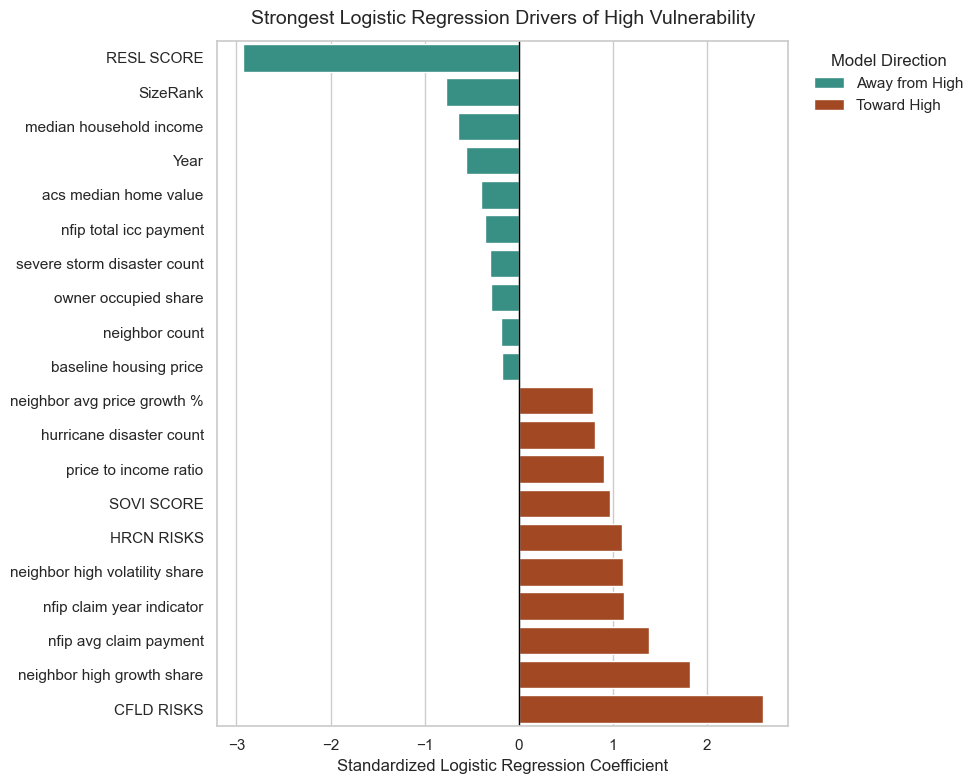

High-vulnerability coefficient figure saved.
Saved figure: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\shap_explainability\high_vulnerability_logistic_regression_coefficients.png


,feature,coefficient,absolute_coefficient,direction
0,RESL_SCORE,-2.9307,2.9307,Away from High
1,CFLD_RISKS,2.5871,2.5871,Toward High
2,neighbor_high_growth_share,1.8181,1.8181,Toward High
3,nfip_avg_claim_payment,1.3848,1.3848,Toward High
4,nfip_claim_year_indicator,1.1128,1.1128,Toward High
5,neighbor_high_volatility_share,1.1041,1.1041,Toward High
6,HRCN_RISKS,1.0960,1.0960,Toward High
7,SOVI_SCORE,0.9710,0.9710,Toward High
8,price_to_income_ratio,0.9082,0.9082,Toward High
9,hurricane_disaster_count,0.8106,0.8106,Toward High


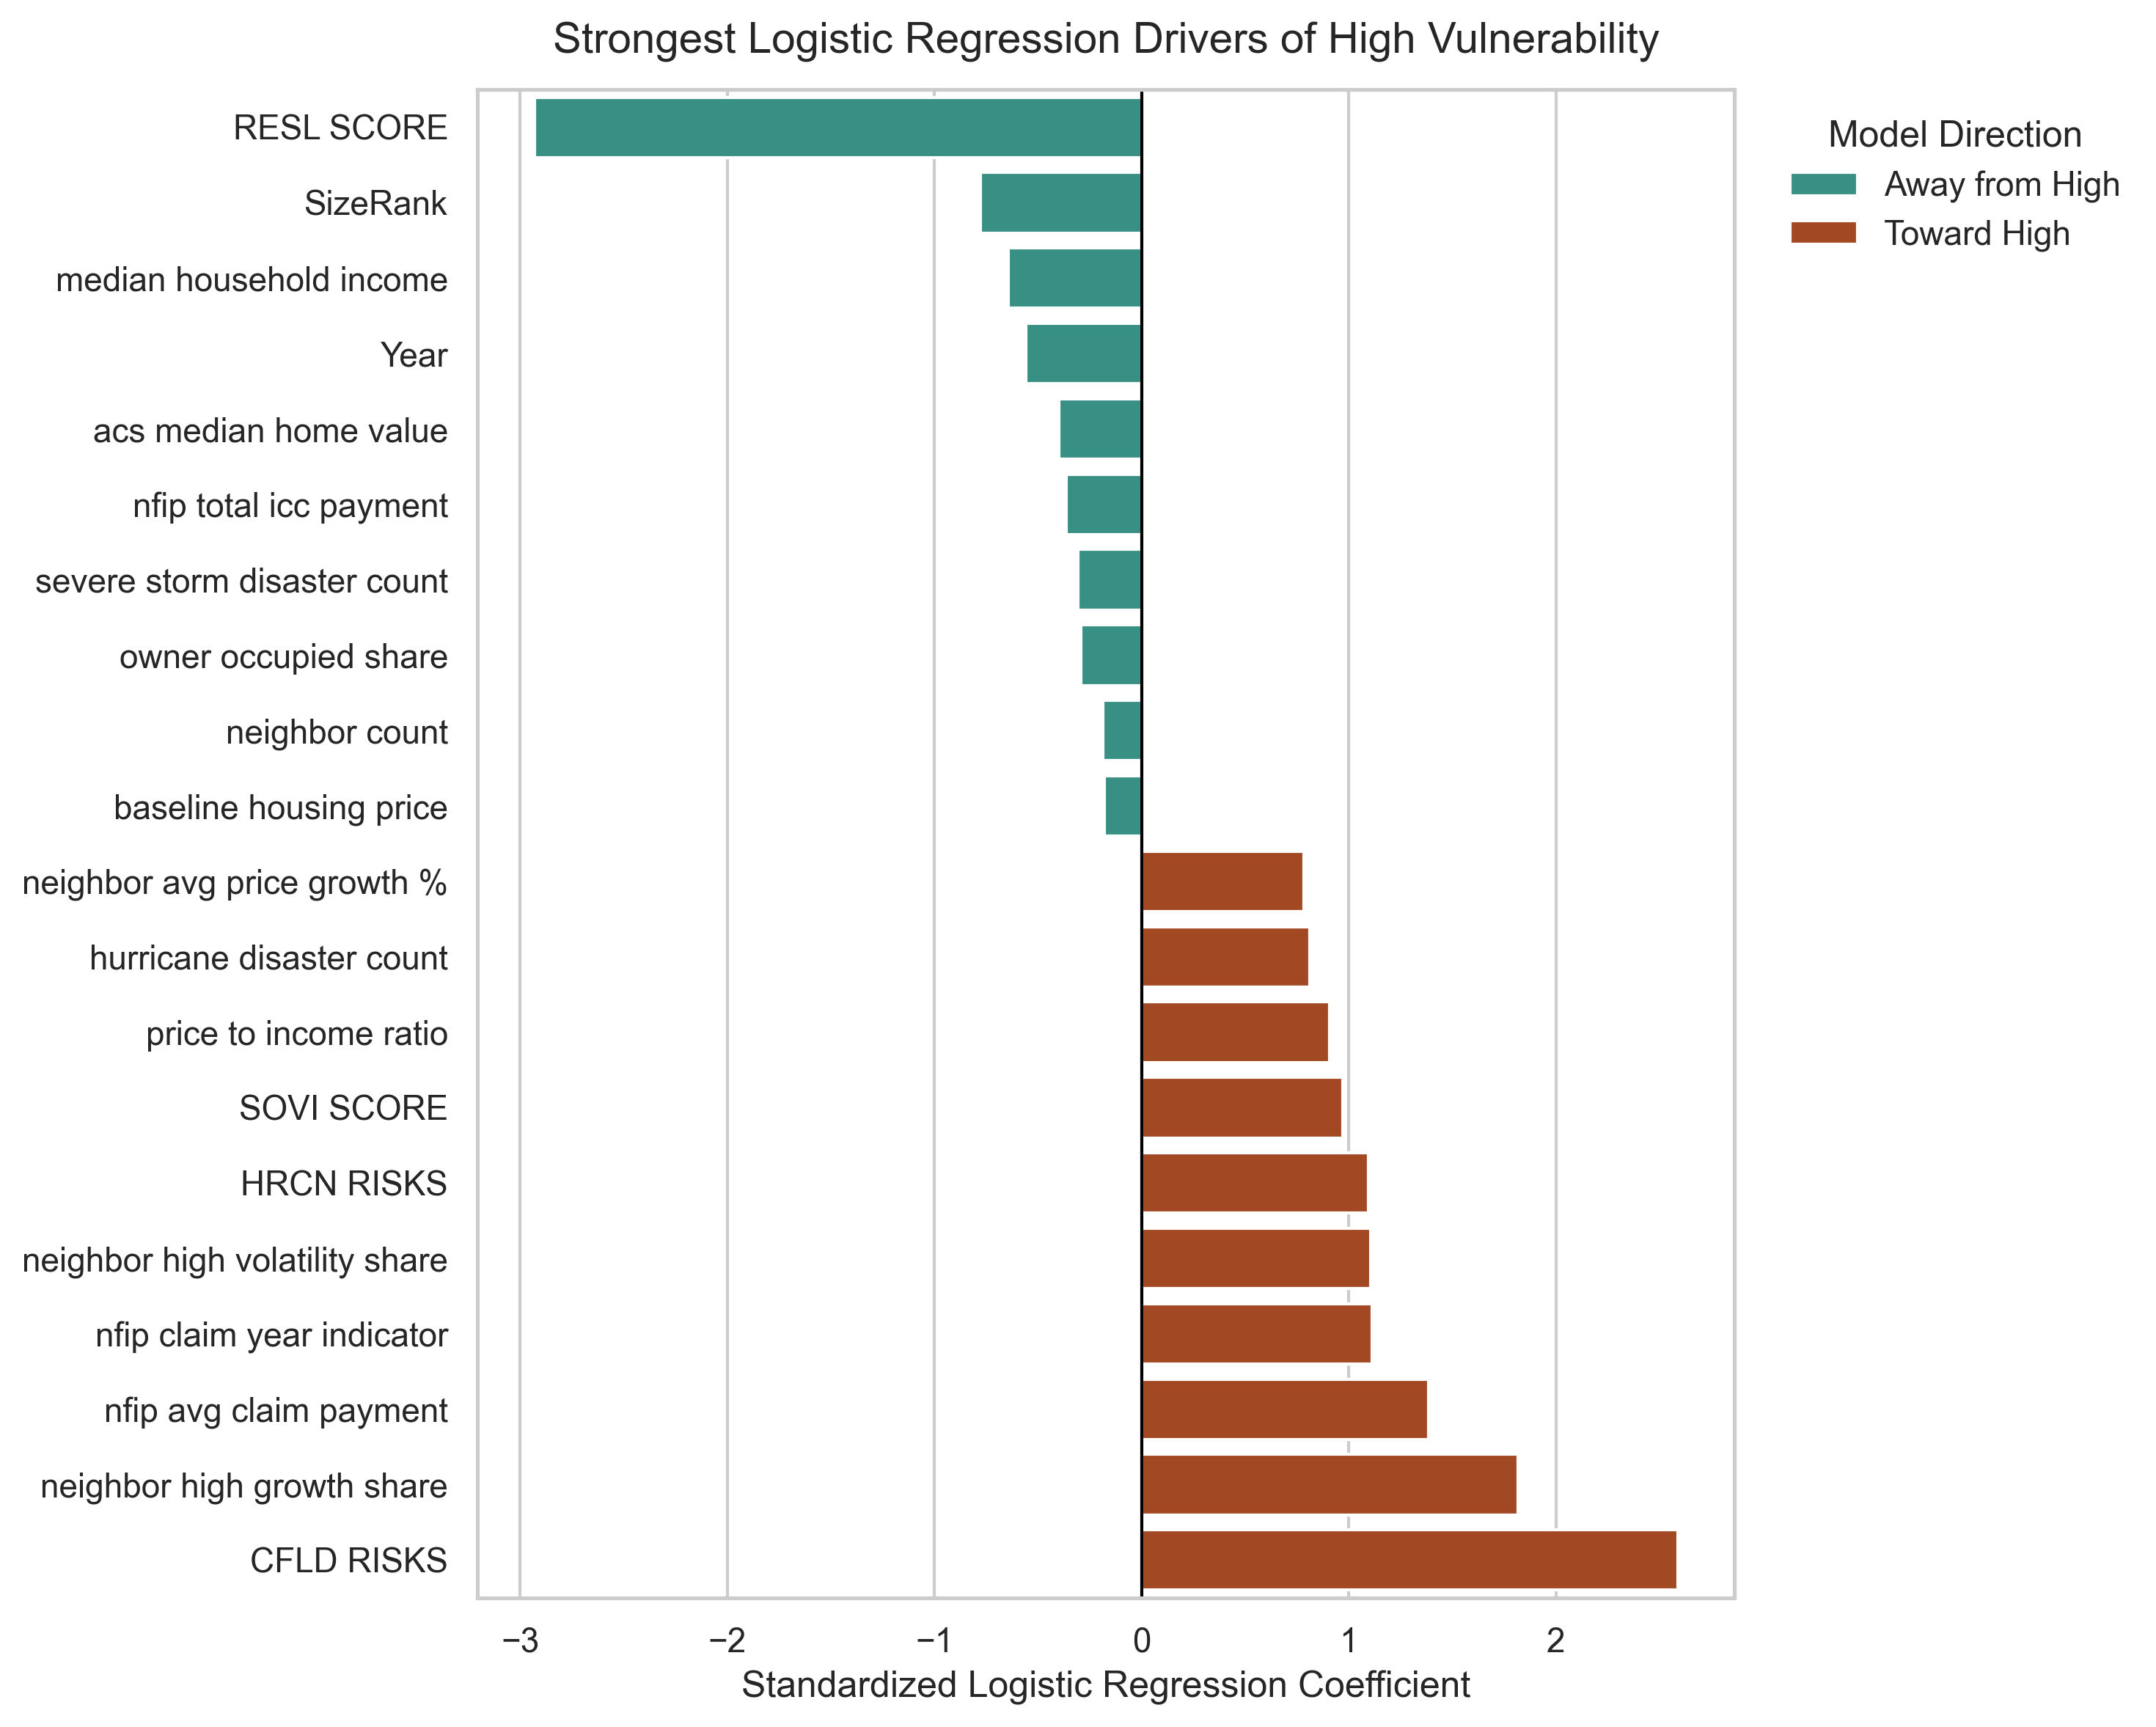

In [6]:
# Select the strongest positive and negative High-class coefficients.
high_coefficient_plot_data = pd.concat(
    [
        high_positive_coefficients.assign(direction="Toward High"),
        high_negative_coefficients.assign(direction="Away from High"),
    ]
)

high_coefficient_plot_data = high_coefficient_plot_data.sort_values(
    "coefficient"
).reset_index(drop=True)

# Create readable labels.
high_coefficient_plot_data["feature_label"] = (
    high_coefficient_plot_data["feature"]
    .str.replace("_", " ", regex=False)
    .str.replace("pct", "%", regex=False)
)

# Plot

plt.figure(figsize=(10, 8))

sns.barplot(
    data=high_coefficient_plot_data,
    x="coefficient",
    y="feature_label",
    hue="direction",
    palette=DIRECTION_COLORS,
    dodge=False,
)

plt.axvline(0, color="black", linewidth=1)

plt.title(
    "Strongest Logistic Regression Drivers of High Vulnerability", fontsize=14, pad=12
)

plt.xlabel("Standardized Logistic Regression Coefficient")
plt.ylabel("")

plt.legend(
    title="Model Direction",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()

coefficient_figure_path = (
    RESULTS_FIGURES / "high_vulnerability_logistic_regression_coefficients.png"
)

plt.savefig(coefficient_figure_path, dpi=300, bbox_inches="tight")

plt.show()

# Compact interpretation table

high_coefficient_summary = (
    high_coefficient_plot_data[
        ["feature", "coefficient", "absolute_coefficient", "direction"]
    ]
    .sort_values("absolute_coefficient", ascending=False)
    .reset_index(drop=True)
)

print("High-vulnerability coefficient figure saved.")
print(f"Saved figure: {coefficient_figure_path}")

display(high_coefficient_summary)

display(Image(filename=str(coefficient_figure_path), width=850))
plt.close("all")


## 3. Global SHAP evidence

Use `LinearExplainer` on the held-out observations and validate exact reconstruction of the model's decision scores. Global mean absolute SHAP values measure influence magnitude, while class-specific signed values show direction on each class score.


In [7]:
# Create SHAP background distribution

background_masker = shap.maskers.Independent(
    X_train_transformed, max_samples=min(500, X_train_transformed.shape[0])
)

# LinearExplainer is appropriate for the fitted
# multinomial Logistic Regression classifier.
linear_explainer = shap.LinearExplainer(logistic_model, masker=background_masker)

shap_explanation = linear_explainer(X_test_transformed)

# Inspect SHAP output structure

shap_values_array = np.asarray(shap_explanation.values)

base_values_array = np.asarray(shap_explanation.base_values)

print("Raw SHAP-value shape:", shap_values_array.shape)
print("Raw base-value shape:", base_values_array.shape)

# Expected structure:
# observations × features × classes
expected_shap_shape = (
    X_test_transformed.shape[0],
    X_test_transformed.shape[1],
    len(model_classes),
)

if shap_values_array.ndim != 3:
    raise ValueError(
        "Unexpected SHAP output structure. "
        f"Observed shape: {shap_values_array.shape}"
    )

if shap_values_array.shape != expected_shap_shape:
    raise ValueError(
        "SHAP dimensions do not match the expected "
        "observations, features, and classes.\n"
        f"Expected: {expected_shap_shape}\n"
        f"Observed: {shap_values_array.shape}"
    )

# Normalize base-value structure

if base_values_array.ndim == 1:
    base_values_matrix = np.tile(base_values_array, (X_test_transformed.shape[0], 1))

elif base_values_array.ndim == 2:
    base_values_matrix = base_values_array

else:
    raise ValueError(
        "Unexpected SHAP base-value structure. "
        f"Observed shape: {base_values_array.shape}"
    )

# Store class-specific SHAP values

shap_values_by_class = {
    class_name: shap_values_array[:, :, class_index]
    for class_index, class_name in enumerate(model_classes)
}

shap_base_values_by_class = {
    class_name: base_values_matrix[:, class_index]
    for class_index, class_name in enumerate(model_classes)
}

# Validate decision-score reconstruction

model_decision_scores = logistic_model.decision_function(X_test_transformed)

reconstructed_decision_scores = base_values_matrix + shap_values_array.sum(axis=1)

maximum_reconstruction_error = np.max(
    np.abs(model_decision_scores - reconstructed_decision_scores)
)

# Create SHAP audit table

shap_audit = pd.DataFrame(
    [
        {
            "check": "SHAP observations",
            "expected": X_test_transformed.shape[0],
            "observed": shap_values_array.shape[0],
            "status": (
                "PASS"
                if shap_values_array.shape[0] == X_test_transformed.shape[0]
                else "FAIL"
            ),
        },
        {
            "check": "SHAP features",
            "expected": X_test_transformed.shape[1],
            "observed": shap_values_array.shape[1],
            "status": (
                "PASS"
                if shap_values_array.shape[1] == X_test_transformed.shape[1]
                else "FAIL"
            ),
        },
        {
            "check": "SHAP classes",
            "expected": len(model_classes),
            "observed": shap_values_array.shape[2],
            "status": (
                "PASS" if shap_values_array.shape[2] == len(model_classes) else "FAIL"
            ),
        },
        {
            "check": "Feature-name alignment",
            "expected": len(readable_feature_names),
            "observed": shap_values_array.shape[1],
            "status": (
                "PASS"
                if len(readable_feature_names) == shap_values_array.shape[1]
                else "FAIL"
            ),
        },
        {
            "check": "Decision-score reconstruction error",
            "expected": "< 1e-8",
            "observed": maximum_reconstruction_error,
            "status": ("PASS" if maximum_reconstruction_error < 1e-8 else "REVIEW"),
        },
    ]
)

print("SHAP values calculated and validated.")
print(f"Model class order: {model_classes}")
print(
    "Maximum decision-score reconstruction error:",
    f"{maximum_reconstruction_error:.12f}",
)

display(shap_audit)


Background dataset has 799 samples but max_samples=500. Subsampling to 500 samples for SHAP value computation. To use all samples, set max_samples=799 when initializing the masker.


Raw SHAP-value shape: (201, 67, 3)
Raw base-value shape: (201, 3)
SHAP values calculated and validated.
Model class order: ['High', 'Low', 'Medium']
Maximum decision-score reconstruction error: 0.000000000000


,check,expected,observed,status
0,SHAP observations,201,201.0000,PASS
1,SHAP features,67,67.0000,PASS
2,SHAP classes,3,3.0000,PASS
3,Feature-name alignment,67,67.0000,PASS
4,Decision-score reconstruction error,< 1e-8,0.0000,PASS


In [8]:
# Calculate overall mean absolute SHAP importance

global_mean_absolute_shap = np.mean(np.abs(shap_values_array), axis=(0, 2))

global_shap_importance = pd.DataFrame(
    {"feature": readable_feature_names, "mean_absolute_shap": global_mean_absolute_shap}
)

global_shap_importance = global_shap_importance.sort_values(
    "mean_absolute_shap", ascending=False
).reset_index(drop=True)

global_shap_importance["global_rank"] = np.arange(1, len(global_shap_importance) + 1)

# Calculate class-specific SHAP importance

class_specific_records = []

for class_index, class_name in enumerate(model_classes):

    class_mean_absolute_shap = np.mean(
        np.abs(shap_values_array[:, :, class_index]), axis=0
    )

    class_table = pd.DataFrame(
        {
            "vulnerability_class": class_name,
            "feature": readable_feature_names,
            "mean_absolute_shap": class_mean_absolute_shap,
        }
    )

    class_table = class_table.sort_values(
        "mean_absolute_shap", ascending=False
    ).reset_index(drop=True)

    class_table["class_rank"] = np.arange(1, len(class_table) + 1)

    class_specific_records.append(class_table)

class_specific_shap_importance = pd.concat(class_specific_records, ignore_index=True)

# Create separate class tables for later analysis.
high_shap_importance = (
    class_specific_shap_importance[
        class_specific_shap_importance["vulnerability_class"] == "High"
    ]
    .copy()
    .reset_index(drop=True)
)

low_shap_importance = (
    class_specific_shap_importance[
        class_specific_shap_importance["vulnerability_class"] == "Low"
    ]
    .copy()
    .reset_index(drop=True)
)

medium_shap_importance = (
    class_specific_shap_importance[
        class_specific_shap_importance["vulnerability_class"] == "Medium"
    ]
    .copy()
    .reset_index(drop=True)
)

# Display global top features

global_top_features = global_shap_importance.head(TOP_FEATURES).copy()

print("Global SHAP feature importance calculated.")
print(
    "Global importance averages absolute SHAP values "
    "across observations and classes."
)

display(global_top_features[["global_rank", "feature", "mean_absolute_shap"]])


Global SHAP feature importance calculated.
Global importance averages absolute SHAP values across observations and classes.


,global_rank,feature,mean_absolute_shap
0,1,RESL_SCORE,1.7391
1,2,CFLD_RISKS,1.6121
2,3,neighbor_high_growth_share,1.5368
3,4,cumulative_climate_disaster_count,1.2224
4,5,recent_3yr_climate_disaster_count,1.1815
5,6,median_household_income,1.1457
6,7,nfip_avg_claim_payment,1.0692
7,8,acs_median_home_value,0.8612
8,9,Year,0.8045
9,10,climate_disaster_count,0.7560


In [9]:
# Combine High- and Low-class importance tables

high_importance_table = high_shap_importance[
    ["feature", "mean_absolute_shap", "class_rank"]
].rename(
    columns={"mean_absolute_shap": "high_mean_absolute_shap", "class_rank": "high_rank"}
)

low_importance_table = low_shap_importance[
    ["feature", "mean_absolute_shap", "class_rank"]
].rename(
    columns={"mean_absolute_shap": "low_mean_absolute_shap", "class_rank": "low_rank"}
)

high_low_shap_comparison = high_importance_table.merge(
    low_importance_table, on="feature", how="outer", validate="one_to_one"
)

# Calculate normalized class contribution shares

high_total_importance = high_low_shap_comparison["high_mean_absolute_shap"].sum()

low_total_importance = high_low_shap_comparison["low_mean_absolute_shap"].sum()

high_low_shap_comparison["high_contribution_pct"] = (
    high_low_shap_comparison["high_mean_absolute_shap"] / high_total_importance * 100
)

high_low_shap_comparison["low_contribution_pct"] = (
    high_low_shap_comparison["low_mean_absolute_shap"] / low_total_importance * 100
)

high_low_shap_comparison["high_minus_low_pct_points"] = (
    high_low_shap_comparison["high_contribution_pct"]
    - high_low_shap_comparison["low_contribution_pct"]
)

high_low_shap_comparison["largest_class_importance"] = high_low_shap_comparison[
    ["high_mean_absolute_shap", "low_mean_absolute_shap"]
].max(axis=1)

# Identify top-feature overlap

top_10_high_features = set(high_shap_importance.head(10)["feature"])

top_10_low_features = set(low_shap_importance.head(10)["feature"])

shared_top_10_features = sorted(top_10_high_features.intersection(top_10_low_features))

high_only_top_10_features = sorted(top_10_high_features.difference(top_10_low_features))

low_only_top_10_features = sorted(top_10_low_features.difference(top_10_high_features))

top_10_overlap_rate = len(shared_top_10_features) / 10 * 100

# Create focused comparison table

focused_feature_set = top_10_high_features.union(top_10_low_features)

high_low_focused_comparison = (
    high_low_shap_comparison[
        high_low_shap_comparison["feature"].isin(focused_feature_set)
    ]
    .sort_values("largest_class_importance", ascending=False)
    .reset_index(drop=True)
)

print("High-versus-Low SHAP comparison completed.")
print(
    f"Shared features in the two top-10 lists: "
    f"{len(shared_top_10_features)} of 10 "
    f"({top_10_overlap_rate:.1f}%)"
)

print("\nShared top-10 features:")
print(shared_top_10_features)

print("\nHigh-only top-10 features:")
print(high_only_top_10_features)

print("\nLow-only top-10 features:")
print(low_only_top_10_features)

display(
    high_low_focused_comparison[
        [
            "feature",
            "high_rank",
            "low_rank",
            "high_mean_absolute_shap",
            "low_mean_absolute_shap",
            "high_contribution_pct",
            "low_contribution_pct",
            "high_minus_low_pct_points",
        ]
    ]
)


High-versus-Low SHAP comparison completed.
Shared features in the two top-10 lists: 7 of 10 (70.0%)

Shared top-10 features:
['CFLD_RISKS', 'RESL_SCORE', 'Year', 'median_household_income', 'neighbor_high_growth_share', 'nfip_avg_claim_payment', 'recent_3yr_climate_disaster_count']

High-only top-10 features:
['climate_disaster_count', 'cumulative_climate_disaster_count', 'nfip_claim_year_indicator']

Low-only top-10 features:
['acs_median_home_value', 'median_gross_rent', 'price_growth_acceleration']


,feature,high_rank,low_rank,high_mean_absolute_shap,low_mean_absolute_shap,high_contribution_pct,low_contribution_pct,high_minus_low_pct_points
0,RESL_SCORE,2,1,2.4149,2.6087,7.3307,7.5957,-0.2650
1,CFLD_RISKS,1,2,2.4181,2.3074,7.3405,6.7185,0.6219
2,neighbor_high_growth_share,3,3,2.3052,1.9443,6.9979,5.6612,1.3367
3,cumulative_climate_disaster_count,4,15,1.8336,0.8904,5.5661,2.5925,2.9736
4,recent_3yr_climate_disaster_count,5,5,1.7723,1.6910,5.3800,4.9237,0.4563
5,median_household_income,7,4,1.2192,1.7185,3.7009,5.0037,-1.3028
6,nfip_avg_claim_payment,6,6,1.4624,1.6038,4.4392,4.6696,-0.2304
7,acs_median_home_value,18,7,0.7227,1.2918,2.1939,3.7612,-1.5673
8,Year,8,9,1.2067,1.0815,3.6631,3.1490,0.5142
9,climate_disaster_count,9,14,1.1340,0.8959,3.4425,2.6086,0.8340


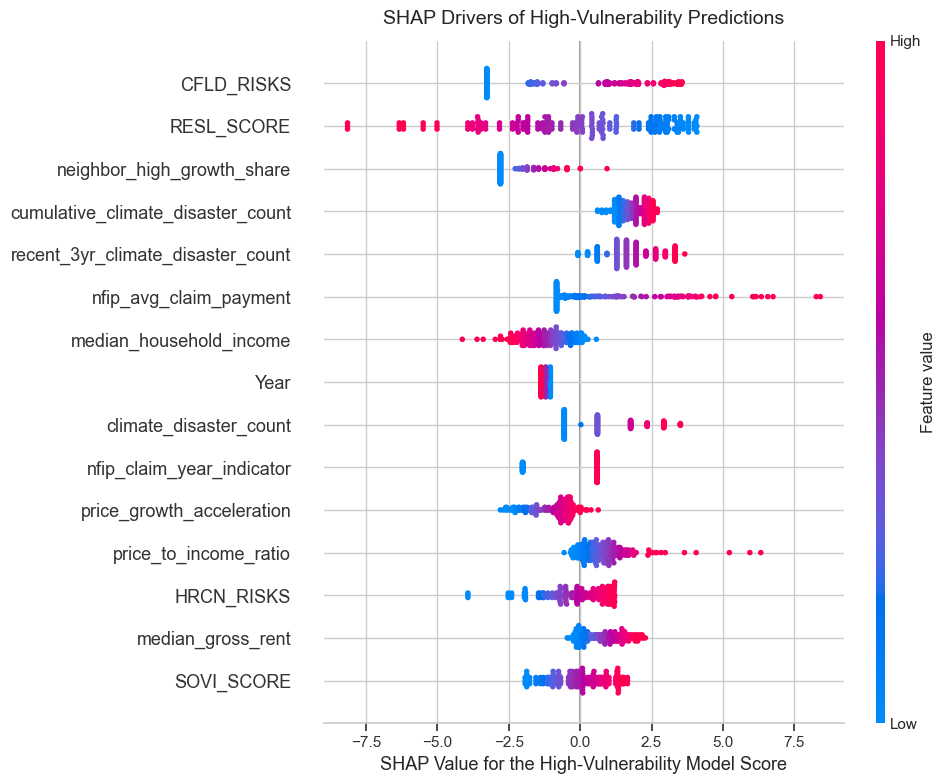

High-vulnerability SHAP beeswarm created.
Saved figure: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\shap_explainability\high_vulnerability_shap_beeswarm.png


,class_rank,feature,mean_absolute_shap
0,1,CFLD_RISKS,2.4181
1,2,RESL_SCORE,2.4149
2,3,neighbor_high_growth_share,2.3052
3,4,cumulative_climate_disaster_count,1.8336
4,5,recent_3yr_climate_disaster_count,1.7723
5,6,nfip_avg_claim_payment,1.4624
6,7,median_household_income,1.2192
7,8,Year,1.2067
8,9,climate_disaster_count,1.1340
9,10,nfip_claim_year_indicator,0.9480


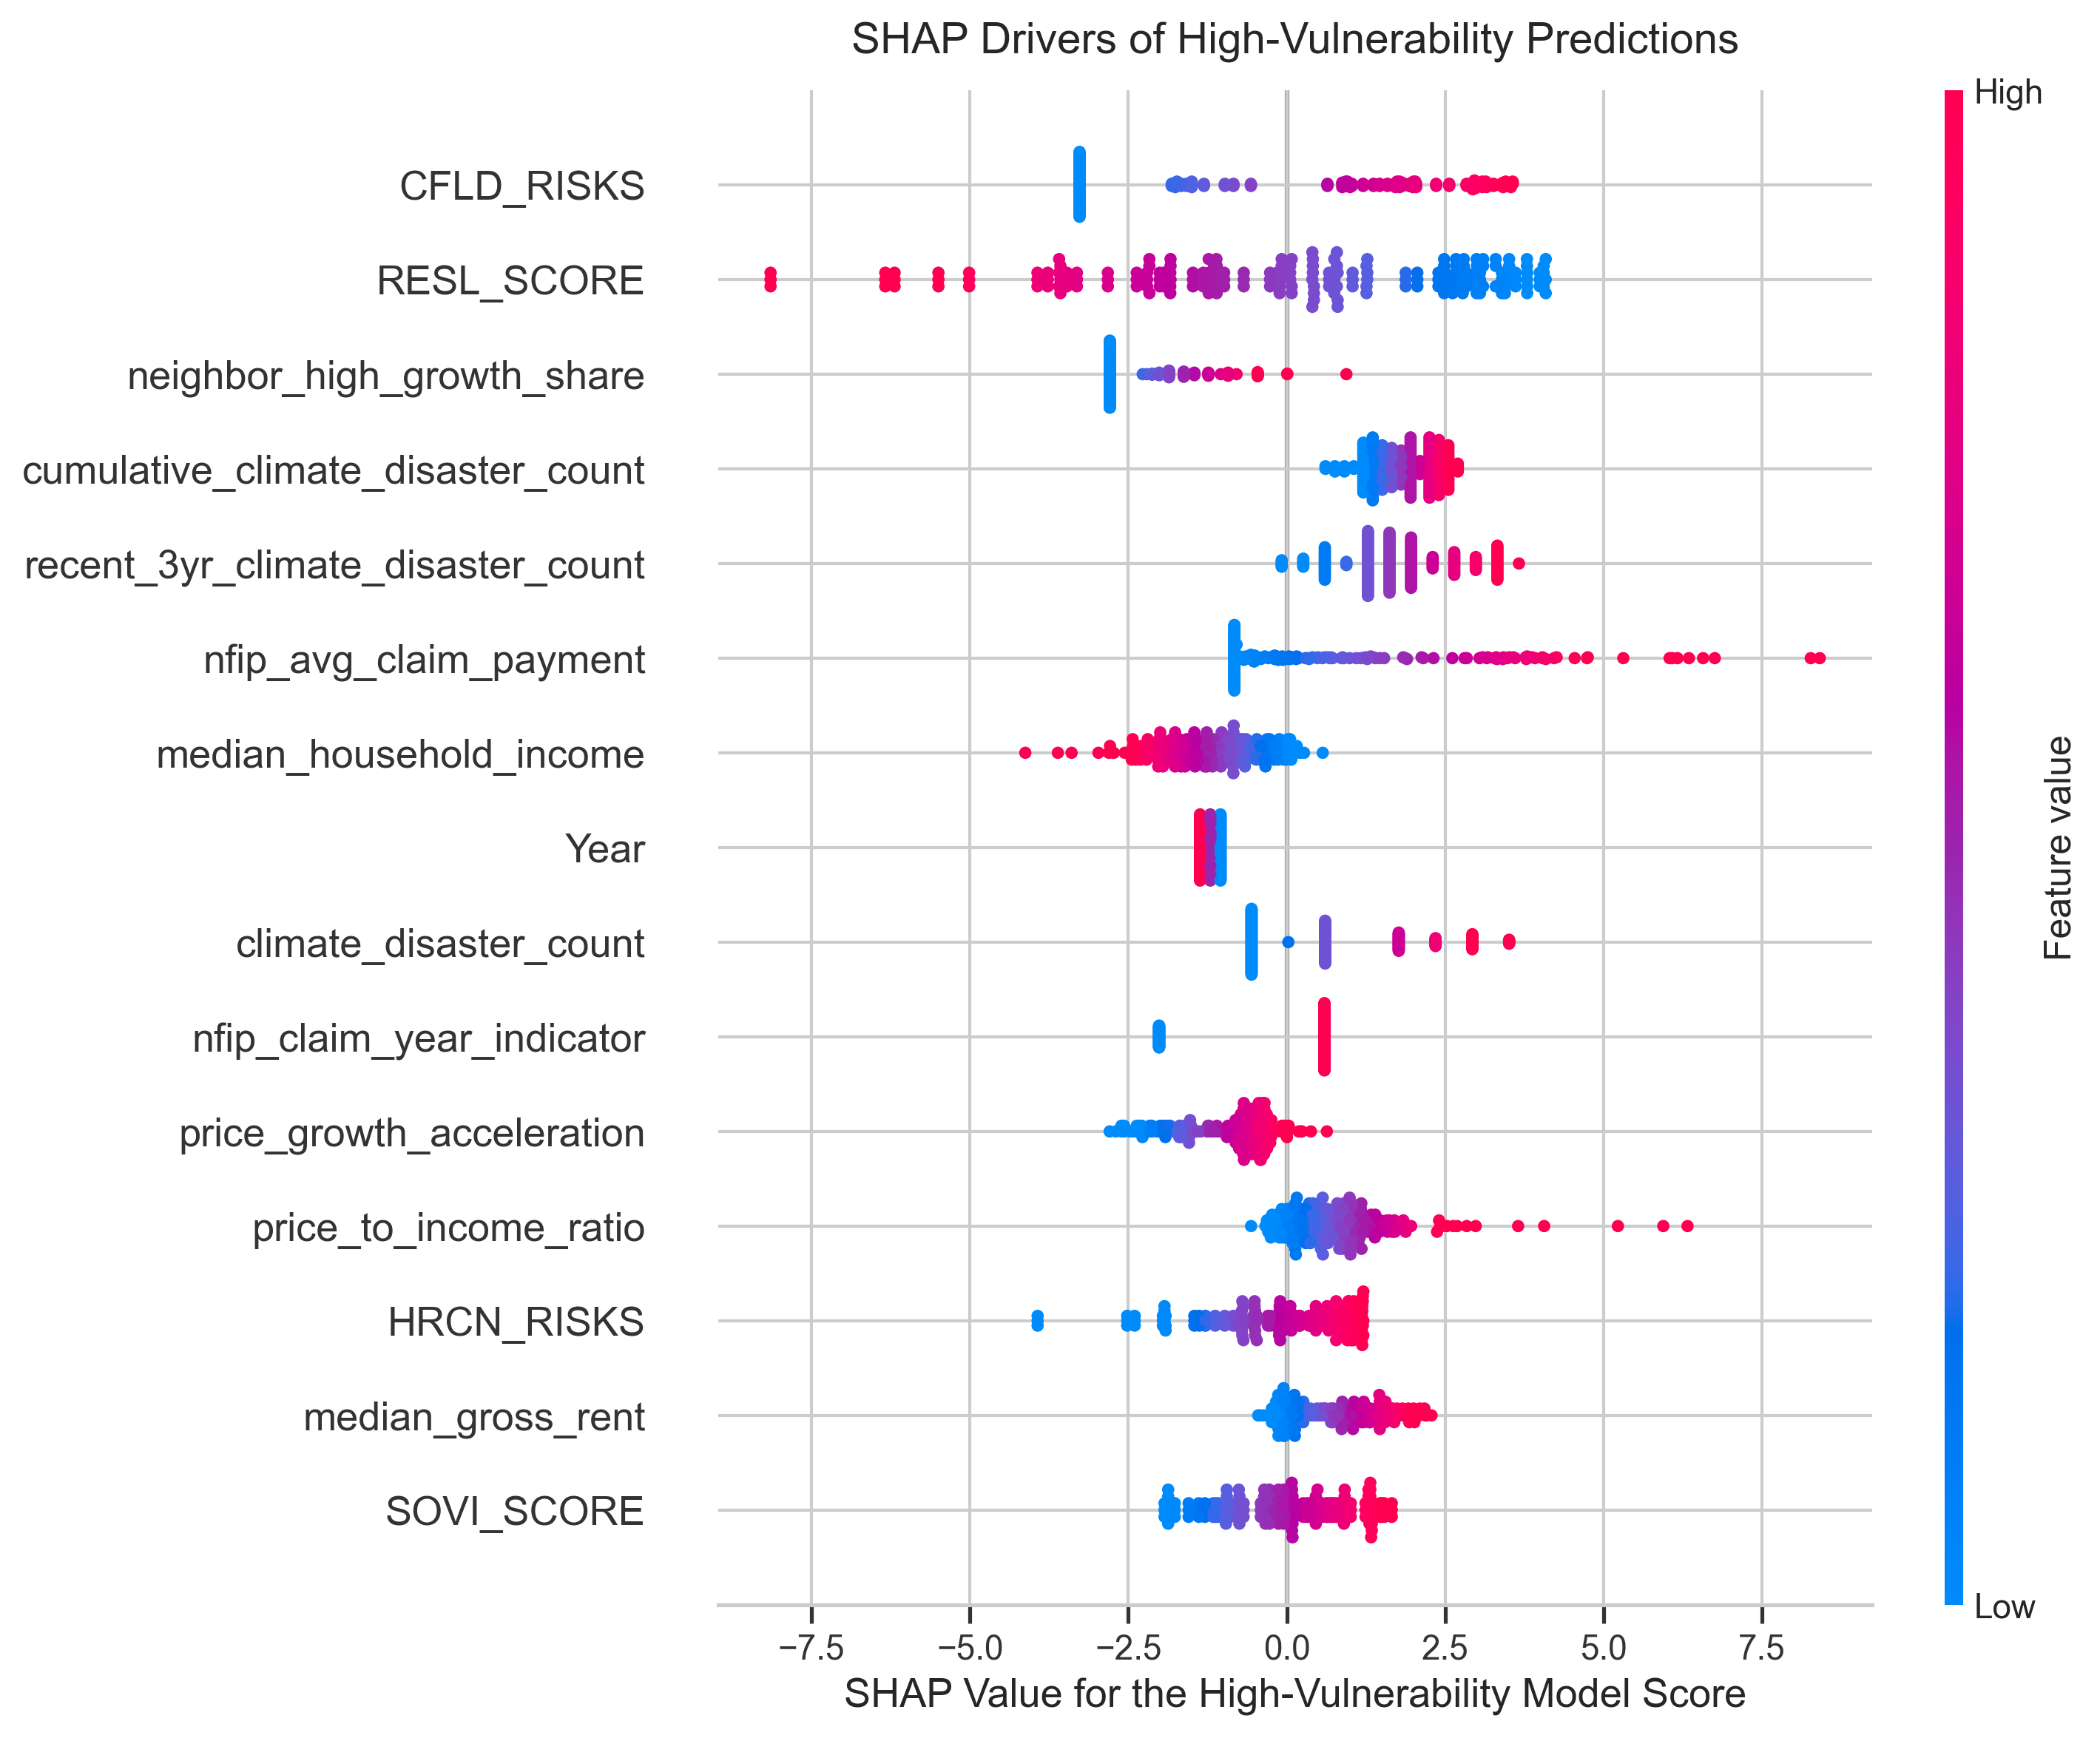

In [10]:
# Create a class-specific SHAP explanation

high_class_index = model_classes.index("High")

high_class_shap_explanation = shap.Explanation(
    values=shap_values_array[:, :, high_class_index],
    base_values=base_values_matrix[:, high_class_index],
    data=X_test_transformed,
    feature_names=readable_feature_names,
)

# Create beeswarm plot

shap.plots.beeswarm(
    high_class_shap_explanation,
    max_display=TOP_FEATURES,
    show=False,
    plot_size=(10, 8),
    group_remaining_features=False,
)

plt.title("SHAP Drivers of High-Vulnerability Predictions", fontsize=14, pad=12)

plt.xlabel("SHAP Value for the High-Vulnerability Model Score")

plt.tight_layout()

high_beeswarm_path = RESULTS_FIGURES / "high_vulnerability_shap_beeswarm.png"

plt.savefig(high_beeswarm_path, dpi=300, bbox_inches="tight")

plt.show()

# Display ranked High-class importance table

high_top_features = high_shap_importance.head(TOP_FEATURES).copy()

print("High-vulnerability SHAP beeswarm created.")
print(f"Saved figure: {high_beeswarm_path}")

display(high_top_features[["class_rank", "feature", "mean_absolute_shap"]])

display(Image(filename=str(high_beeswarm_path), width=850))
plt.close("all")


## 4. Contributions by vulnerability dimension

Map all 67 predictors to the project's analytical dimensions. The grouped totals describe collective contribution; the per-feature averages prevent large feature groups from appearing influential only because they contain more variables. Year remains a temporal control and is excluded from the vulnerability-dimension chart.


In [11]:
# Recover cumulative feature-group definitions

validated_groups = feature_group_definitions["validated_feature_groups"]

housing_features = set(validated_groups["Housing Only"])

climate_features = set(validated_groups["Housing + Climate"]) - housing_features

disaster_features = set(validated_groups["Housing + Climate + Disaster"]) - set(
    validated_groups["Housing + Climate"]
)

socioeconomic_features = set(
    validated_groups["Housing + Climate + Disaster + ACS"]
) - set(validated_groups["Housing + Climate + Disaster"])

full_layer_features = set(validated_groups["Full Model"]) - set(
    validated_groups["Housing + Climate + Disaster + ACS"]
)

# Assign each predictor to an analytical dimension

feature_dimension_map = {}

for feature in model_feature_list:

    # Year is retained by the model as a temporal
    # control but is not treated as a vulnerability dimension.
    if feature == "Year":
        dimension = "Temporal Control"

    # Separate resilience from the broader FEMA layer.
    elif feature == "RESL_SCORE":
        dimension = "Resilience"

    # Treat social vulnerability as socioeconomic stress.
    elif feature == "SOVI_SCORE":
        dimension = "Socioeconomic and Affordability Stress"

    elif feature in housing_features:
        dimension = "Housing Pressure and Market Conditions"

    elif feature in climate_features:
        dimension = "Climate Exposure"

    elif feature in disaster_features:
        dimension = "Disaster History"

    elif feature in socioeconomic_features:
        dimension = "Socioeconomic and Affordability Stress"

    elif feature in full_layer_features:

        if feature.startswith("nfip_"):
            dimension = "Insurance-Loss Stress"

        elif feature.startswith("neighbor_"):
            dimension = "Spatial Spillover"

        else:
            dimension = "Unmapped"

    else:
        dimension = "Unmapped"

    feature_dimension_map[feature] = dimension

# Create feature-dimension table

feature_dimension_table = pd.DataFrame(
    {
        "feature": model_feature_list,
        "feature_dimension": [
            feature_dimension_map[feature] for feature in model_feature_list
        ],
    }
)

unmapped_features = feature_dimension_table.loc[
    feature_dimension_table["feature_dimension"] == "Unmapped", "feature"
].tolist()

if unmapped_features:
    raise ValueError(
        "The following features were not assigned to an "
        f"analytical dimension: {unmapped_features}"
    )

# Create mapping audit

feature_dimension_audit = (
    feature_dimension_table.groupby("feature_dimension", as_index=False)
    .agg(
        feature_count=("feature", "size"),
        example_features=("feature", lambda values: ", ".join(list(values)[:5])),
    )
    .sort_values("feature_count", ascending=False)
    .reset_index(drop=True)
)

mapped_feature_count = len(feature_dimension_table)

print("SHAP feature-dimension mapping completed.")
print(f"Mapped features: {mapped_feature_count}")
print(f"Unmapped features: {len(unmapped_features)}")
print("Temporal control excluded from vulnerability-group " "contribution charts: Year")

display(feature_dimension_audit)
display(feature_dimension_table)


SHAP feature-dimension mapping completed.
Mapped features: 67
Unmapped features: 0
Temporal control excluded from vulnerability-group contribution charts: Year


,feature_dimension,feature_count,example_features
0,Housing Pressure and Market Conditions,15,"avg_annual_housing_price, median_annual_housin..."
1,Disaster History,14,"disaster_count, unique_disaster_events, climat..."
2,Insurance-Loss Stress,14,"nfip_claim_count, nfip_policy_count_sum, nfip_..."
3,Socioeconomic and Affordability Stress,14,"is_metro, SizeRank, POPULATION, SOVI_SCORE, ac..."
4,Spatial Spillover,6,"neighbor_count, neighbor_avg_housing_price, ne..."
5,Climate Exposure,2,"CFLD_RISKS, HRCN_RISKS"
6,Resilience,1,RESL_SCORE
7,Temporal Control,1,Year


,feature,feature_dimension
0,Year,Temporal Control
1,avg_annual_housing_price,Housing Pressure and Market Conditions
2,median_annual_housing_price,Housing Pressure and Market Conditions
3,min_annual_housing_price,Housing Pressure and Market Conditions
4,max_annual_housing_price,Housing Pressure and Market Conditions
5,annual_price_volatility,Housing Pressure and Market Conditions
6,monthly_observations,Housing Pressure and Market Conditions
7,is_metro,Socioeconomic and Affordability Stress
8,SizeRank,Socioeconomic and Affordability Stress
9,POPULATION,Socioeconomic and Affordability Stress


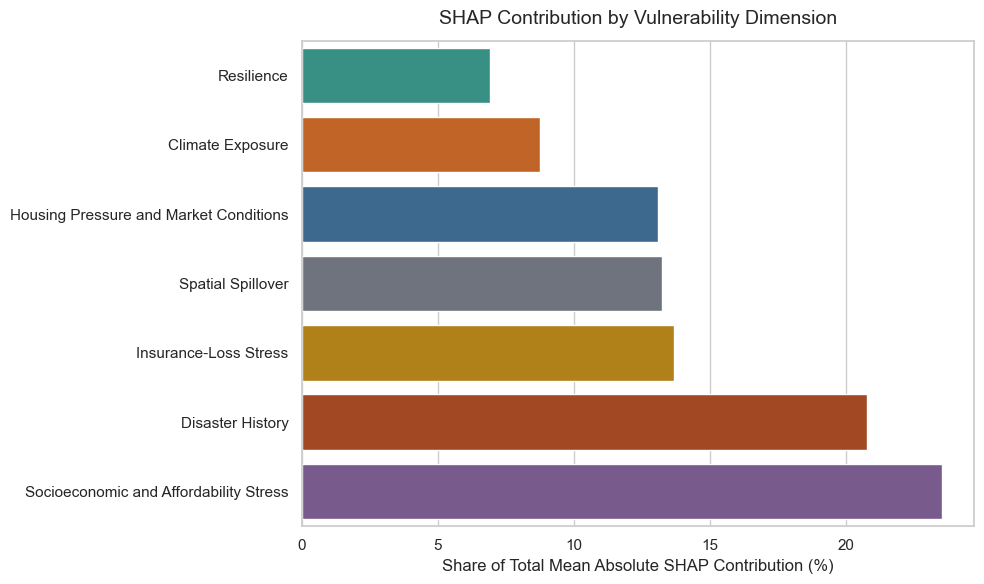

Grouped SHAP contribution analysis completed.
Saved figure: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\shap_explainability\shap_contribution_by_vulnerability_dimension.png


,group_rank,feature_dimension,feature_count,group_contribution_pct,average_shap_per_feature,leading_feature,leading_feature_shap
0,1,Socioeconomic and Affordability Stress,14,23.5246,0.4218,median_household_income,1.1457
1,2,Disaster History,14,20.7767,0.3725,cumulative_climate_disaster_count,1.2224
2,3,Insurance-Loss Stress,14,13.6920,0.2455,nfip_avg_claim_payment,1.0692
3,4,Spatial Spillover,6,13.2333,0.5536,neighbor_high_growth_share,1.5368
4,5,Housing Pressure and Market Conditions,15,13.0905,0.2190,price_growth_acceleration,0.6582
5,6,Climate Exposure,2,8.7541,1.0986,CFLD_RISKS,1.6121
6,7,Resilience,1,6.9289,1.7391,RESL_SCORE,1.7391


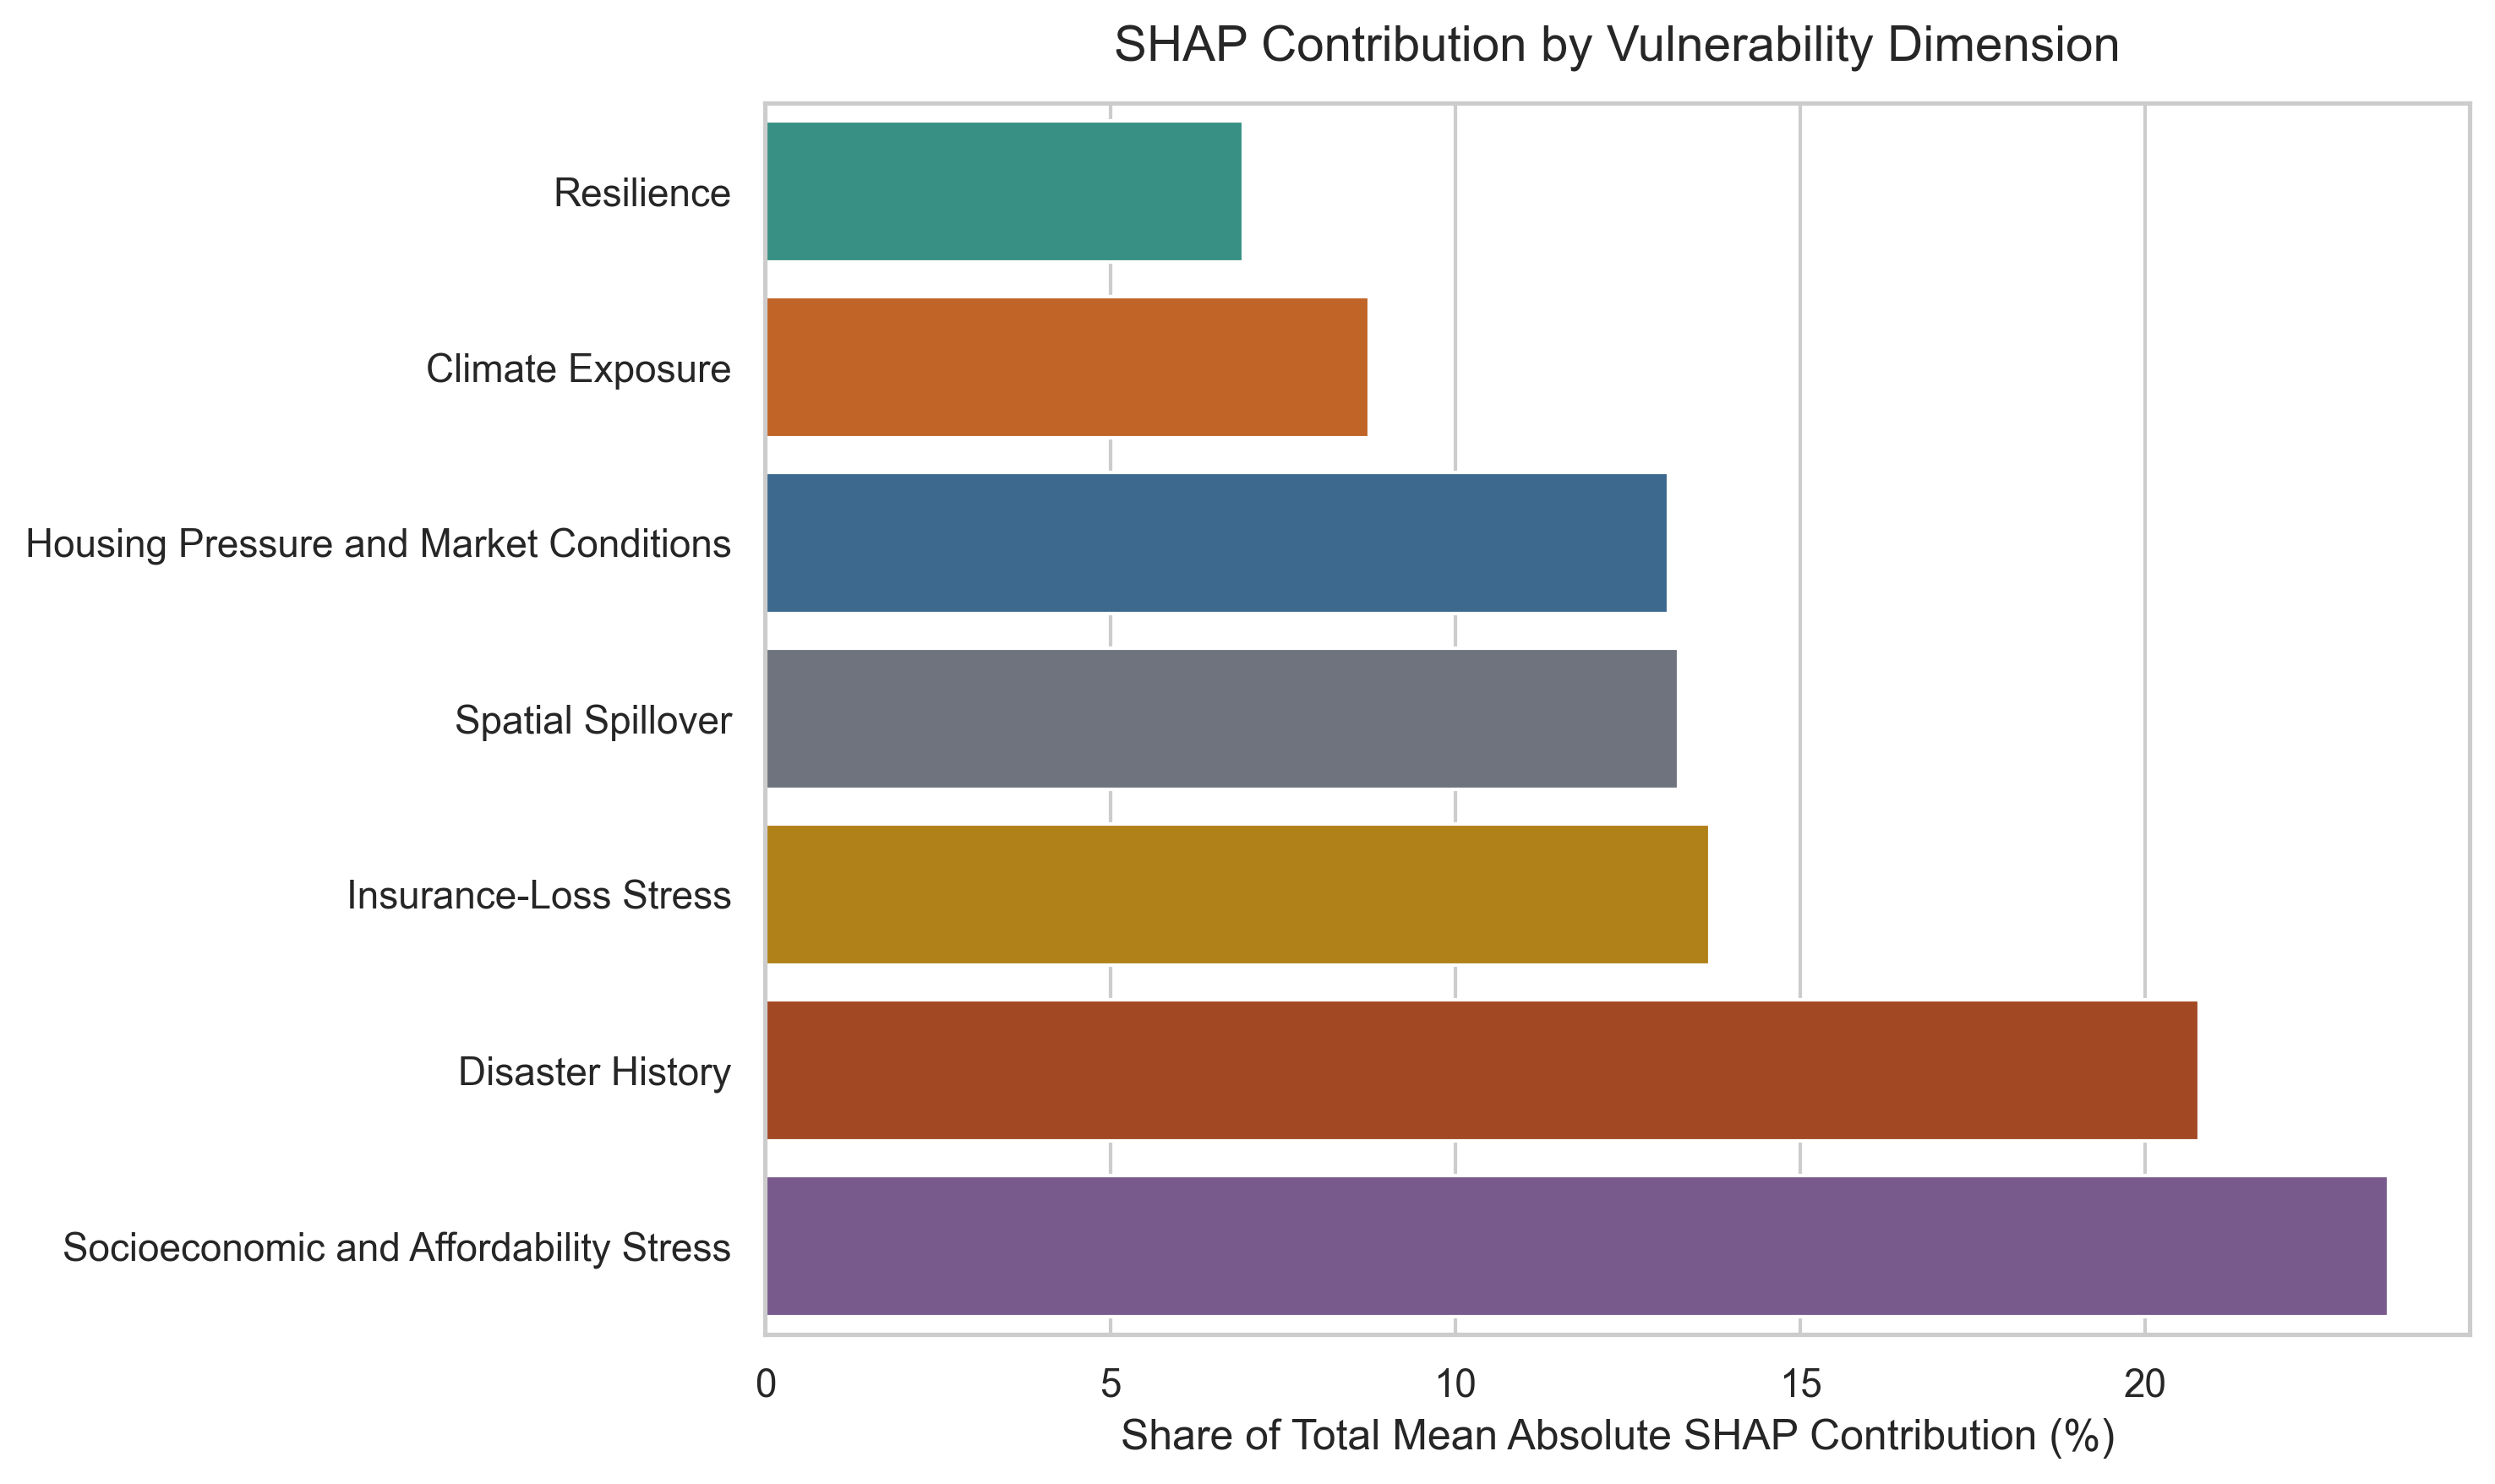

In [12]:
# Prepare feature-level SHAP importance

feature_group_shap = global_shap_importance[["feature", "mean_absolute_shap"]].merge(
    feature_dimension_table, on="feature", how="left", validate="one_to_one"
)

# Exclude Year from the vulnerability-dimension comparison.
feature_group_shap = feature_group_shap[
    feature_group_shap["feature_dimension"] != "Temporal Control"
].copy()

# Aggregate SHAP values by dimension

grouped_shap_importance = feature_group_shap.groupby(
    "feature_dimension", as_index=False
).agg(
    feature_count=("feature", "size"),
    total_mean_absolute_shap=("mean_absolute_shap", "sum"),
    average_shap_per_feature=("mean_absolute_shap", "mean"),
    maximum_feature_shap=("mean_absolute_shap", "max"),
)

total_grouped_importance = grouped_shap_importance["total_mean_absolute_shap"].sum()

grouped_shap_importance["group_contribution_pct"] = (
    grouped_shap_importance["total_mean_absolute_shap"] / total_grouped_importance * 100
)

grouped_shap_importance = grouped_shap_importance.sort_values(
    "group_contribution_pct", ascending=False
).reset_index(drop=True)

grouped_shap_importance["group_rank"] = np.arange(1, len(grouped_shap_importance) + 1)

# Identify the leading feature in each dimension

leading_group_features = (
    feature_group_shap.sort_values(
        ["feature_dimension", "mean_absolute_shap"], ascending=[True, False]
    )
    .groupby("feature_dimension", as_index=False)
    .first()[["feature_dimension", "feature", "mean_absolute_shap"]]
    .rename(
        columns={
            "feature": "leading_feature",
            "mean_absolute_shap": "leading_feature_shap",
        }
    )
)

grouped_shap_importance = grouped_shap_importance.merge(
    leading_group_features, on="feature_dimension", how="left", validate="one_to_one"
)

# Plot grouped contribution percentages

plot_data = grouped_shap_importance.sort_values(
    "group_contribution_pct", ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="group_contribution_pct",
    y="feature_dimension",
    hue="feature_dimension",
    palette=DIMENSION_COLORS,
    legend=False,
)

plt.title("SHAP Contribution by Vulnerability Dimension", fontsize=14, pad=12)

plt.xlabel("Share of Total Mean Absolute SHAP Contribution (%)")

plt.ylabel("")

plt.tight_layout()

grouped_shap_figure_path = (
    RESULTS_FIGURES / "shap_contribution_by_vulnerability_dimension.png"
)

plt.savefig(grouped_shap_figure_path, dpi=300, bbox_inches="tight")

plt.show()

# Display grouped results

print("Grouped SHAP contribution analysis completed.")
print(f"Saved figure: {grouped_shap_figure_path}")

display(
    grouped_shap_importance[
        [
            "group_rank",
            "feature_dimension",
            "feature_count",
            "group_contribution_pct",
            "average_shap_per_feature",
            "leading_feature",
            "leading_feature_shap",
        ]
    ]
)

display(Image(filename=str(grouped_shap_figure_path), width=850))
plt.close("all")


## 5. Medium-class uncertainty

Summarize the probability structure and profile composition of actual and predicted Medium observations. This section treats Medium vulnerability as an overlapping transition range rather than a uniform substantive condition.


In [13]:
# Isolate actual Medium-vulnerability observations

medium_cases = explainability_data[
    explainability_data["actual_vulnerability_class"] == "Medium"
].copy()

medium_cases["medium_prediction_group"] = np.select(
    [
        medium_cases["predicted_vulnerability_class"] == "Medium",
        medium_cases["predicted_vulnerability_class"] == "Low",
        medium_cases["predicted_vulnerability_class"] == "High",
    ],
    ["Correctly Predicted Medium", "Predicted Low", "Predicted High"],
    default="Other",
)

prediction_group_order = [
    "Correctly Predicted Medium",
    "Predicted Low",
    "Predicted High",
]

medium_cases["medium_prediction_group"] = pd.Categorical(
    medium_cases["medium_prediction_group"],
    categories=prediction_group_order,
    ordered=True,
)

# Summarize prediction confidence and probabilities

medium_probability_summary = medium_cases.groupby(
    "medium_prediction_group", observed=False, as_index=False
).agg(
    observations=("STCOFIPS", "size"),
    mean_probability_medium=("probability_medium", "mean"),
    mean_probability_low=("probability_low", "mean"),
    mean_probability_high=("probability_high", "mean"),
    mean_predicted_probability=("predicted_probability", "mean"),
    mean_probability_margin=("probability_margin", "mean"),
)

# Compare selected influential indicators

medium_indicator_columns = [
    "RESL_SCORE",
    "CFLD_RISKS",
    "neighbor_high_growth_share",
    "cumulative_climate_disaster_count",
    "recent_3yr_climate_disaster_count",
    "nfip_avg_claim_payment",
    "median_household_income",
    "price_to_income_ratio",
]

available_medium_indicators = [
    column for column in medium_indicator_columns if column in medium_cases.columns
]

medium_indicator_summary = (
    medium_cases.groupby("medium_prediction_group", observed=False)[
        available_medium_indicators
    ]
    .mean()
    .reset_index()
)

# Examine cluster-profile composition

medium_cluster_composition = (
    medium_cases.groupby(["medium_prediction_group", "cluster_name"], observed=False)
    .size()
    .reset_index(name="observations")
)

medium_cluster_composition["group_total"] = medium_cluster_composition.groupby(
    "medium_prediction_group", observed=False
)["observations"].transform("sum")

medium_cluster_composition["within_group_pct"] = (
    medium_cluster_composition["observations"]
    / medium_cluster_composition["group_total"]
    * 100
)

medium_cluster_composition = (
    medium_cluster_composition[medium_cluster_composition["observations"] > 0]
    .sort_values(["medium_prediction_group", "observations"], ascending=[True, False])
    .reset_index(drop=True)
)

# Display results

print("Medium-class uncertainty analysis completed.")
print(f"Actual Medium observations: {len(medium_cases)}")

display(medium_probability_summary)
display(medium_indicator_summary)
display(
    medium_cluster_composition[
        ["medium_prediction_group", "cluster_name", "observations", "within_group_pct"]
    ]
)


Medium-class uncertainty analysis completed.
Actual Medium observations: 79


,medium_prediction_group,observations,mean_probability_medium,mean_probability_low,mean_probability_high,mean_predicted_probability,mean_probability_margin
0,Correctly Predicted Medium,38,0.7765,0.1182,0.1053,0.7765,0.5710
1,Predicted Low,33,0.1375,0.8605,0.0019,0.8605,0.7230
2,Predicted High,8,0.2804,0.0064,0.7132,0.7132,0.4328


,medium_prediction_group,RESL_SCORE,CFLD_RISKS,neighbor_high_growth_share,cumulative_climate_disaster_count,recent_3yr_climate_disaster_count,nfip_avg_claim_payment,median_household_income,price_to_income_ratio
0,Correctly Predicted Medium,36.3985,29.2263,0.1647,15.0789,7.6316,"18,110.9647","66,190.0526",4.7782
1,Predicted Low,33.4288,45.3212,0.0465,15.4545,5.8788,"5,644.8062","69,817.9273",4.5067
2,Predicted High,36.7366,60.0250,0.1375,16.2500,7.0000,"28,862.2059","66,179.6875",4.9152


,medium_prediction_group,cluster_name,observations,within_group_pct
0,Correctly Predicted Medium,Disaster-Loss Growth Pressure,21,55.2632
1,Correctly Predicted Medium,Socioeconomic Resilience Stress,14,36.8421
2,Correctly Predicted Medium,Lower-Stress Resilient Profile,2,5.2632
3,Correctly Predicted Medium,High-Exposure Latent Risk,1,2.6316
4,Predicted Low,Socioeconomic Resilience Stress,12,36.3636
5,Predicted Low,Lower-Stress Resilient Profile,11,33.3333
6,Predicted Low,Disaster-Loss Growth Pressure,7,21.2121
7,Predicted Low,High-Exposure Latent Risk,3,9.0909
8,Predicted High,Disaster-Loss Growth Pressure,6,75.0000
9,Predicted High,High-Exposure Latent Risk,1,12.5000


## 6. Selected county-year explanations

Select four predefined 2025 cases representing distinct pathways: Miami-Dade, Collier, Jefferson, and Saint Johns. Waterfalls explain the class predicted for each observation, using original feature values for labels and transformed values for SHAP calculations.


In [14]:
case_selection_sources = {
    "Hidden-risk assessment": hidden_risk_assessment,
    "Hidden-risk sensitivity": hidden_risk_sensitivity,
    "County cluster membership": county_cluster_membership,
    "Holdout explainability data": explainability_data,
}

for source_name, source_data in case_selection_sources.items():

    print("=" * 70)
    print(source_name)
    print(f"Shape: {source_data.shape}")
    print("Columns:")

    for column_name in source_data.columns:
        print(f"- {column_name}")

    print()


Hidden-risk assessment
Shape: (67, 27)
Columns:
- STCOFIPS
- RegionName
- recent_avg_annual_growth_pct
- recent_median_annual_growth_pct
- recent_avg_vulnerability_score
- recent_avg_climate_exposure_score
- recent_avg_disaster_history_score
- recent_avg_insurance_loss_score
- risk_cluster_years
- high_vulnerability_years
- recent_years_observed
- risk_cluster_share_pct
- high_vulnerability_share_pct
- latest_cluster_id
- latest_cluster_name
- latest_vulnerability_score
- latest_vulnerability_class
- dominant_recent_cluster_id
- dominant_recent_cluster_name
- recent_cluster_transitions
- persistent_risk_profile
- current_or_dominant_risk_profile
- strong_recent_growth
- top_quartile_recent_growth
- hidden_risk_flag
- priority_hidden_risk_flag
- hidden_risk_category

Hidden-risk sensitivity
Shape: (67, 12)
Columns:
- STCOFIPS
- RegionName
- recent_avg_annual_growth_pct
- recent_avg_vulnerability_score
- risk_cluster_share_pct
- high_vulnerability_years
- latest_cluster_name
- dominant_r

In [15]:
# Prepare county-level hidden-risk context

hidden_risk_context_columns = [
    "STCOFIPS",
    "hidden_risk_flag",
    "priority_hidden_risk_flag",
    "hidden_risk_category",
    "strong_recent_growth",
    "top_quartile_recent_growth",
    "risk_cluster_share_pct",
    "high_vulnerability_share_pct",
]

hidden_risk_context = hidden_risk_assessment[hidden_risk_context_columns].copy()

sensitivity_context_columns = [
    "STCOFIPS",
    "scenarios_selected",
    "selection_rate_pct",
    "selected_in_all_scenarios",
    "selected_in_majority_of_scenarios",
]

sensitivity_context = hidden_risk_sensitivity[sensitivity_context_columns].copy()

# Add county-level context to holdout observations

case_selection_data = explainability_data.merge(
    hidden_risk_context, on="STCOFIPS", how="left", validate="many_to_one"
).merge(sensitivity_context, on="STCOFIPS", how="left", validate="many_to_one")

# Use the latest holdout year for current county stories.
latest_holdout_year = int(case_selection_data["Year"].max())

latest_case_data = case_selection_data[
    case_selection_data["Year"] == latest_holdout_year
].copy()

# Common display columns

case_display_columns = [
    "Year",
    "STCOFIPS",
    "RegionName",
    "actual_vulnerability_class",
    "predicted_vulnerability_class",
    "prediction_correct",
    "probability_high",
    "probability_low",
    "probability_medium",
    "predicted_probability",
    "probability_margin",
    "cluster_name",
    "annual_price_growth_pct",
    "CFLD_RISKS",
    "SOVI_SCORE",
    "RESL_SCORE",
    "nfip_avg_claim_payment",
    "scenarios_selected",
    "selection_rate_pct",
    "priority_hidden_risk_flag",
]

case_display_columns = [
    column for column in case_display_columns if column in latest_case_data.columns
]

# Candidate Pool 1:
# Robust hidden-risk strong-market counties

robust_hidden_risk_candidates = (
    latest_case_data[
        latest_case_data["selected_in_majority_of_scenarios"].fillna(False)
    ]
    .sort_values(
        ["scenarios_selected", "probability_high", "annual_price_growth_pct"],
        ascending=[False, False, False],
    )[case_display_columns]
    .reset_index(drop=True)
)

# Candidate Pool 2:
# Correctly predicted Disaster-Loss Growth Pressure

disaster_loss_candidates = (
    latest_case_data[
        (latest_case_data["cluster_name"] == "Disaster-Loss Growth Pressure")
        & latest_case_data["prediction_correct"]
    ]
    .sort_values(
        ["probability_high", "nfip_avg_claim_payment"], ascending=[False, False]
    )[case_display_columns]
    .head(10)
    .reset_index(drop=True)
)

# Candidate Pool 3:
# Socioeconomic Resilience Stress

socioeconomic_stress_candidates = (
    latest_case_data[
        (latest_case_data["cluster_name"] == "Socioeconomic Resilience Stress")
        & latest_case_data["prediction_correct"]
    ]
    .sort_values(["SOVI_SCORE", "probability_high"], ascending=[False, False])[
        case_display_columns
    ]
    .head(10)
    .reset_index(drop=True)
)

# Candidate Pool 4:
# Confident Lower-Stress Resilient cases

resilient_low_candidates = (
    latest_case_data[
        (latest_case_data["cluster_name"] == "Lower-Stress Resilient Profile")
        & (latest_case_data["actual_vulnerability_class"] == "Low")
        & (latest_case_data["predicted_vulnerability_class"] == "Low")
    ]
    .sort_values(["probability_low", "RESL_SCORE"], ascending=[False, False])[
        case_display_columns
    ]
    .head(10)
    .reset_index(drop=True)
)

# Display candidate pools

print(f"County-year case-selection pools created " f"for {latest_holdout_year}.")

print("\n1. Robust hidden-risk candidates")
display(robust_hidden_risk_candidates)

print("\n2. Disaster-Loss Growth Pressure candidates")
display(disaster_loss_candidates)

print("\n3. Socioeconomic Resilience Stress candidates")
display(socioeconomic_stress_candidates)

print("\n4. Lower-Stress Resilient candidates")
display(resilient_low_candidates)


County-year case-selection pools created for 2025.

1. Robust hidden-risk candidates


,Year,STCOFIPS,RegionName,actual_vulnerability_class,predicted_vulnerability_class,prediction_correct,probability_high,probability_low,probability_medium,predicted_probability,probability_margin,cluster_name,annual_price_growth_pct,CFLD_RISKS,SOVI_SCORE,RESL_SCORE,nfip_avg_claim_payment,scenarios_selected,selection_rate_pct,priority_hidden_risk_flag
0,2025,12086,Miami-Dade County,High,High,True,0.9995,0.0000,0.0005,0.9995,0.9990,High-Exposure Latent Risk,-1.1850,99.6000,75.8588,42.9071,"28,903.8419",8,100.0000,True
1,2025,12021,Collier County,High,High,True,0.9995,0.0000,0.0005,0.9995,0.9989,Disaster-Loss Growth Pressure,-6.7571,95.2000,74.7137,41.2850,"8,482.2373",8,100.0000,True
2,2025,12087,Monroe County,High,High,True,0.9800,0.0000,0.0200,0.9800,0.9601,Disaster-Loss Growth Pressure,-4.3833,98.8000,53.9440,29.3893,"29,327.4347",8,100.0000,True
3,2025,12053,Hernando County,Medium,High,False,0.8781,0.0071,0.1148,0.8781,0.7633,Disaster-Loss Growth Pressure,-3.1260,74.2000,56.4885,6.0751,0.0000,8,100.0000,True
4,2025,12075,Levy County,Medium,Low,False,0.0044,0.8968,0.0989,0.8968,0.7979,Socioeconomic Resilience Stress,-1.3703,72.6000,93.4478,9.1603,0.0000,7,87.5000,True
5,2025,12029,Dixie County,Medium,Low,False,0.0001,0.9745,0.0255,0.9745,0.9490,Socioeconomic Resilience Stress,0.5435,73.6000,57.0929,2.9898,0.0000,7,87.5000,True
6,2025,12057,Hillsborough County,High,High,True,1.0000,0.0000,0.0000,1.0000,1.0000,Disaster-Loss Growth Pressure,-3.7196,92.4000,36.3868,33.2379,"16,021.5887",5,62.5000,False
7,2025,12081,Manatee County,High,High,True,0.9998,0.0000,0.0002,0.9998,0.9996,Disaster-Loss Growth Pressure,-6.8529,98.0000,54.8346,22.7735,"1,146.2933",5,62.5000,False
8,2025,12101,Pasco County,High,High,True,0.9997,0.0000,0.0003,0.9997,0.9994,Disaster-Loss Growth Pressure,-4.8512,90.8000,39.6628,10.4326,0.0000,5,62.5000,False
9,2025,12017,Citrus County,High,High,True,0.9989,0.0000,0.0011,0.9989,0.9978,High-Exposure Latent Risk,-3.3325,92.6000,82.2837,6.8384,0.0000,5,62.5000,False



2. Disaster-Loss Growth Pressure candidates


,Year,STCOFIPS,RegionName,actual_vulnerability_class,predicted_vulnerability_class,prediction_correct,probability_high,probability_low,probability_medium,predicted_probability,probability_margin,cluster_name,annual_price_growth_pct,CFLD_RISKS,SOVI_SCORE,RESL_SCORE,nfip_avg_claim_payment,scenarios_selected,selection_rate_pct,priority_hidden_risk_flag
0,2025,12103,Pinellas County,High,High,True,1.0000,0.0000,0.0000,1.0000,1.0000,Disaster-Loss Growth Pressure,-6.8423,99.2000,59.9237,10.9097,"4,137.9896",0,0.0000,False
1,2025,12071,Lee County,High,High,True,1.0000,0.0000,0.0000,1.0000,1.0000,Disaster-Loss Growth Pressure,-8.8393,97.4000,67.8435,8.7786,"2,125.6800",0,0.0000,False
2,2025,12057,Hillsborough County,High,High,True,1.0000,0.0000,0.0000,1.0000,1.0000,Disaster-Loss Growth Pressure,-3.7196,92.4000,36.3868,33.2379,"16,021.5887",5,62.5000,False
3,2025,12115,Sarasota County,High,High,True,1.0000,0.0000,0.0000,1.0000,1.0000,Disaster-Loss Growth Pressure,-8.9862,93.6000,67.0165,9.1921,"1,854.8450",0,0.0000,False
4,2025,12081,Manatee County,High,High,True,0.9998,0.0000,0.0002,0.9998,0.9996,Disaster-Loss Growth Pressure,-6.8529,98.0000,54.8346,22.7735,"1,146.2933",5,62.5000,False
5,2025,12101,Pasco County,High,High,True,0.9997,0.0000,0.0003,0.9997,0.9994,Disaster-Loss Growth Pressure,-4.8512,90.8000,39.6628,10.4326,0.0000,5,62.5000,False
6,2025,12021,Collier County,High,High,True,0.9995,0.0000,0.0005,0.9995,0.9989,Disaster-Loss Growth Pressure,-6.7571,95.2000,74.7137,41.2850,"8,482.2373",8,100.0000,True
7,2025,12087,Monroe County,High,High,True,0.9800,0.0000,0.0200,0.9800,0.9601,Disaster-Loss Growth Pressure,-4.3833,98.8000,53.9440,29.3893,"29,327.4347",8,100.0000,True
8,2025,12095,Orange County,Medium,Medium,True,0.0255,0.0037,0.9708,0.9708,0.9452,Disaster-Loss Growth Pressure,-2.6421,0.0000,31.7430,41.2532,"55,210.0964",0,0.0000,False



3. Socioeconomic Resilience Stress candidates


,Year,STCOFIPS,RegionName,actual_vulnerability_class,predicted_vulnerability_class,prediction_correct,probability_high,probability_low,probability_medium,predicted_probability,probability_margin,cluster_name,annual_price_growth_pct,CFLD_RISKS,SOVI_SCORE,RESL_SCORE,nfip_avg_claim_payment,scenarios_selected,selection_rate_pct,priority_hidden_risk_flag
0,2025,12065,Jefferson County,Low,Low,True,0.0000,0.9998,0.0002,0.9998,0.9996,Socioeconomic Resilience Stress,-0.3195,39.4000,97.9008,32.1883,0.0000,0,0.0000,False
1,2025,12039,Gadsden County,Low,Low,True,0.0000,0.9999,0.0001,0.9999,0.9999,Socioeconomic Resilience Stress,-0.6887,0.0000,95.0382,33.8104,0.0000,0,0.0000,False
2,2025,12043,Glades County,Low,Low,True,0.0000,0.9610,0.0390,0.9610,0.9221,Socioeconomic Resilience Stress,0.0663,0.0000,89.7265,0.9224,0.0000,0,0.0000,False
3,2025,12047,Hamilton County,Low,Low,True,0.0000,0.9994,0.0006,0.9994,0.9988,Socioeconomic Resilience Stress,-0.2997,0.0000,89.0267,8.3969,0.0000,0,0.0000,False
4,2025,12079,Madison County,Low,Low,True,0.0000,0.9999,0.0001,0.9999,0.9997,Socioeconomic Resilience Stress,1.6198,0.0000,79.9618,22.6781,0.0000,0,0.0000,False
5,2025,12063,Jackson County,Low,Low,True,0.0000,1.0000,0.0000,1.0000,1.0000,Socioeconomic Resilience Stress,-0.8651,0.0000,78.7214,26.4313,0.0000,0,0.0000,False
6,2025,12041,Gilchrist County,Low,Low,True,0.0000,0.9999,0.0001,0.9999,0.9999,Socioeconomic Resilience Stress,0.9787,25.8000,73.4733,10.7824,0.0000,0,0.0000,False
7,2025,12013,Calhoun County,Low,Low,True,0.0000,0.9998,0.0002,0.9998,0.9997,Socioeconomic Resilience Stress,-3.6119,21.2000,73.1234,13.8995,0.0000,0,0.0000,False
8,2025,12023,Columbia County,Low,Low,True,0.0000,0.9999,0.0001,0.9999,0.9998,Socioeconomic Resilience Stress,0.5079,0.0000,71.4059,29.2621,0.0000,0,0.0000,False
9,2025,12121,Suwannee County,Low,Low,True,0.0000,0.9988,0.0012,0.9988,0.9976,Socioeconomic Resilience Stress,1.7114,0.0000,60.1145,5.1845,0.0000,0,0.0000,False



4. Lower-Stress Resilient candidates


,Year,STCOFIPS,RegionName,actual_vulnerability_class,predicted_vulnerability_class,prediction_correct,probability_high,probability_low,probability_medium,predicted_probability,probability_margin,cluster_name,annual_price_growth_pct,CFLD_RISKS,SOVI_SCORE,RESL_SCORE,nfip_avg_claim_payment,scenarios_selected,selection_rate_pct,priority_hidden_risk_flag
0,2025,12003,Baker County,Low,Low,True,0.0000,1.0000,0.0000,1.0000,1.0000,Lower-Stress Resilient Profile,0.9194,0.0000,24.4275,71.7875,0.0000,0,0.0000,False
1,2025,12129,Wakulla County,Low,Low,True,0.0000,1.0000,0.0000,1.0000,1.0000,Lower-Stress Resilient Profile,-0.7005,61.2000,12.7545,42.2392,0.0000,0,0.0000,False
2,2025,12109,Saint Johns County,Low,Low,True,0.0000,1.0000,0.0000,1.0000,1.0000,Lower-Stress Resilient Profile,-3.3286,89.0000,11.3868,96.2786,"18,198.9025",0,0.0000,False
3,2025,12001,Alachua County,Low,Low,True,0.0000,1.0000,0.0000,1.0000,1.0000,Lower-Stress Resilient Profile,-1.5900,0.0000,34.7646,80.9796,0.0000,0,0.0000,False
4,2025,12089,Nassau County,Low,Low,True,0.0000,1.0000,0.0000,1.0000,1.0000,Lower-Stress Resilient Profile,-1.1539,75.8000,20.5471,75.5725,"2,128.8100",0,0.0000,False
5,2025,12113,Santa Rosa County,Low,Low,True,0.0000,1.0000,0.0000,1.0000,1.0000,Lower-Stress Resilient Profile,-1.6170,70.8000,12.1819,54.6756,"5,224.1400",0,0.0000,False
6,2025,12073,Leon County,Low,Low,True,0.0000,1.0000,0.0000,1.0000,1.0000,Lower-Stress Resilient Profile,-0.8218,23.4000,35.0827,82.1247,"8,756.6300",0,0.0000,False
7,2025,12119,Sumter County,Low,Low,True,0.0000,1.0000,0.0000,1.0000,0.9999,Lower-Stress Resilient Profile,-1.4280,0.0000,90.0445,46.9784,0.0000,0,0.0000,False
8,2025,12045,Gulf County,Low,Low,True,0.0000,0.9999,0.0001,0.9999,0.9999,Lower-Stress Resilient Profile,-3.4721,61.6000,65.6807,58.4924,0.0000,2,25.0000,False
9,2025,12019,Clay County,Low,Low,True,0.0000,0.9999,0.0001,0.9999,0.9998,Lower-Stress Resilient Profile,-2.0607,57.0000,12.9453,51.1132,"20,745.0275",0,0.0000,False


In [16]:
# Add recent multi-year county context

recent_context_columns = [
    "STCOFIPS",
    "recent_avg_annual_growth_pct",
    "recent_avg_vulnerability_score",
    "recent_avg_climate_exposure_score",
    "recent_avg_disaster_history_score",
    "recent_avg_insurance_loss_score",
]

latest_case_enriched = latest_case_data.merge(
    hidden_risk_assessment[recent_context_columns],
    on="STCOFIPS",
    how="left",
    validate="one_to_one",
)

# Case 1:
# Robust hidden risk through structural exposure

exposure_hidden_risk_case = (
    latest_case_enriched[
        latest_case_enriched["selected_in_all_scenarios"].fillna(False)
        & (latest_case_enriched["cluster_name"] == "High-Exposure Latent Risk")
        & (latest_case_enriched["actual_vulnerability_class"] == "High")
        & (latest_case_enriched["predicted_vulnerability_class"] == "High")
    ]
    .sort_values("probability_high", ascending=False)
    .head(1)
    .copy()
)

exposure_hidden_risk_case["case_label"] = "Robust Hidden Exposure"

exposure_hidden_risk_case["case_rationale"] = (
    "Selected in all sensitivity scenarios and classified "
    "as High within the High-Exposure Latent Risk profile."
)

# Case 2:
# Robust hidden risk through disaster-loss pressure

disaster_hidden_risk_case = (
    latest_case_enriched[
        latest_case_enriched["selected_in_all_scenarios"].fillna(False)
        & (latest_case_enriched["cluster_name"] == "Disaster-Loss Growth Pressure")
        & (latest_case_enriched["actual_vulnerability_class"] == "High")
        & (latest_case_enriched["predicted_vulnerability_class"] == "High")
    ]
    .sort_values("probability_high", ascending=False)
    .head(1)
    .copy()
)

disaster_hidden_risk_case["case_label"] = "Robust Disaster-Loss Pressure"

disaster_hidden_risk_case["case_rationale"] = (
    "Selected in all sensitivity scenarios and classified "
    "as High within the Disaster-Loss Growth Pressure profile."
)

# Case 3:
# Socioeconomic stress with Low severity

socioeconomic_case = (
    latest_case_enriched[
        (latest_case_enriched["cluster_name"] == "Socioeconomic Resilience Stress")
        & (latest_case_enriched["actual_vulnerability_class"] == "Low")
        & (latest_case_enriched["predicted_vulnerability_class"] == "Low")
    ]
    .sort_values("SOVI_SCORE", ascending=False)
    .head(1)
    .copy()
)

socioeconomic_case["case_label"] = "Socioeconomic Stress Pathway"

socioeconomic_case["case_rationale"] = (
    "Highest social vulnerability among correctly predicted "
    "Low cases in the Socioeconomic Resilience Stress profile."
)

# Case 4:
# Strong resilience offsetting exposure

resilient_case = (
    latest_case_enriched[
        (latest_case_enriched["cluster_name"] == "Lower-Stress Resilient Profile")
        & (latest_case_enriched["actual_vulnerability_class"] == "Low")
        & (latest_case_enriched["predicted_vulnerability_class"] == "Low")
    ]
    .sort_values("RESL_SCORE", ascending=False)
    .head(1)
    .copy()
)

resilient_case["case_label"] = "Resilience-Based Protection"

resilient_case["case_rationale"] = (
    "Strongest resilience among correctly predicted Low cases "
    "in the Lower-Stress Resilient Profile."
)

# Combine and validate selected cases

selected_case_studies = pd.concat(
    [
        exposure_hidden_risk_case,
        disaster_hidden_risk_case,
        socioeconomic_case,
        resilient_case,
    ],
    ignore_index=True,
)

if len(selected_case_studies) != 4:
    raise ValueError("The expected four county-year cases were not selected.")

if selected_case_studies[["Year", "STCOFIPS"]].duplicated().any():
    raise ValueError("Duplicate county-year cases were selected.")

selected_case_studies["case_order"] = np.arange(1, len(selected_case_studies) + 1)

selected_case_columns = [
    "case_order",
    "case_label",
    "RegionName",
    "Year",
    "actual_vulnerability_class",
    "predicted_vulnerability_class",
    "predicted_probability",
    "probability_high",
    "probability_low",
    "cluster_name",
    "recent_avg_annual_growth_pct",
    "annual_price_growth_pct",
    "CFLD_RISKS",
    "SOVI_SCORE",
    "RESL_SCORE",
    "nfip_avg_claim_payment",
    "scenarios_selected",
    "selection_rate_pct",
    "case_rationale",
]

print("Four county-year SHAP case studies selected.")

display(selected_case_studies[selected_case_columns])


Four county-year SHAP case studies selected.


,case_order,case_label,RegionName,Year,actual_vulnerability_class,predicted_vulnerability_class,predicted_probability,probability_high,probability_low,cluster_name,recent_avg_annual_growth_pct,annual_price_growth_pct,CFLD_RISKS,SOVI_SCORE,RESL_SCORE,nfip_avg_claim_payment,scenarios_selected,selection_rate_pct,case_rationale
0,1,Robust Hidden Exposure,Miami-Dade County,2025,High,High,0.9995,0.9995,0.0000,High-Exposure Latent Risk,10.0276,-1.1850,99.6000,75.8588,42.9071,"28,903.8419",8,100.0000,Selected in all sensitivity scenarios and clas...
1,2,Robust Disaster-Loss Pressure,Collier County,2025,High,High,0.9995,0.9995,0.0000,Disaster-Loss Growth Pressure,10.5318,-6.7571,95.2000,74.7137,41.2850,"8,482.2373",8,100.0000,Selected in all sensitivity scenarios and clas...
2,3,Socioeconomic Stress Pathway,Jefferson County,2025,Low,Low,0.9998,0.0000,0.9998,Socioeconomic Resilience Stress,9.0738,-0.3195,39.4000,97.9008,32.1883,0.0000,0,0.0000,Highest social vulnerability among correctly p...
3,4,Resilience-Based Protection,Saint Johns County,2025,Low,Low,1.0000,0.0000,1.0000,Lower-Stress Resilient Profile,8.9082,-3.3286,89.0000,11.3868,96.2786,"18,198.9025",0,0.0000,Strongest resilience among correctly predicted...


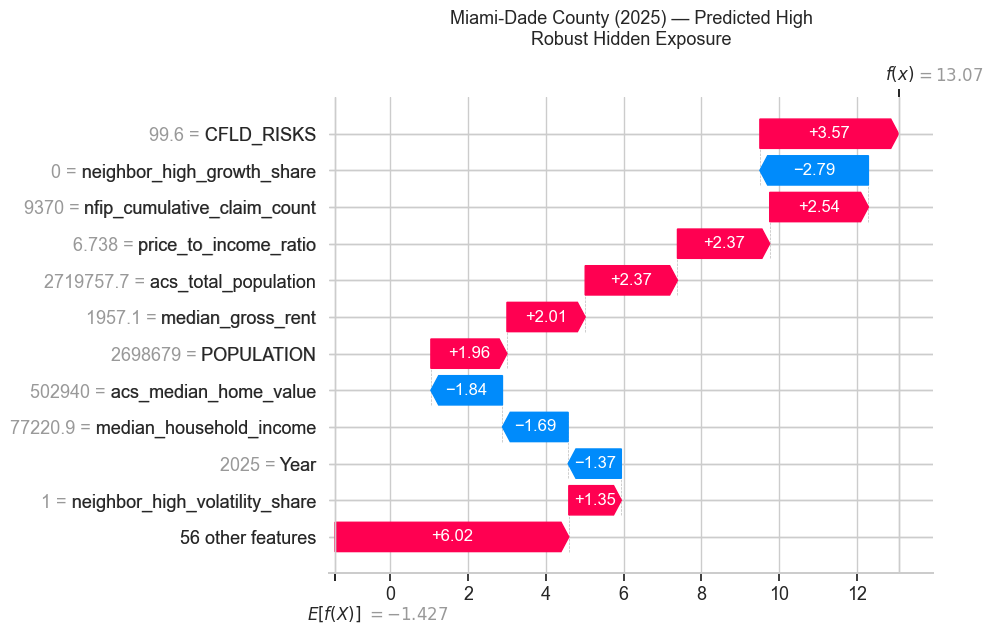

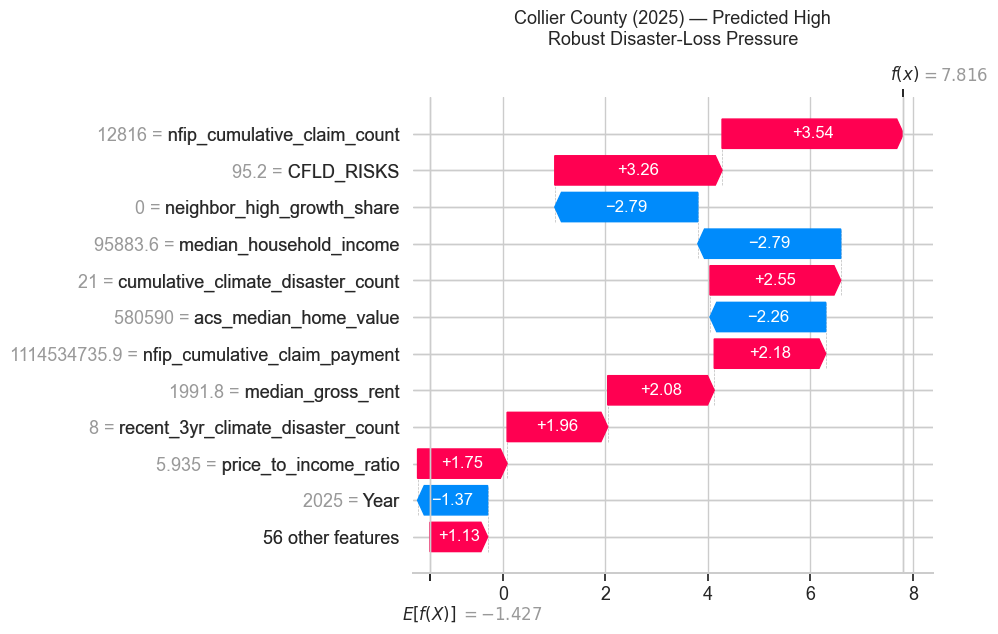

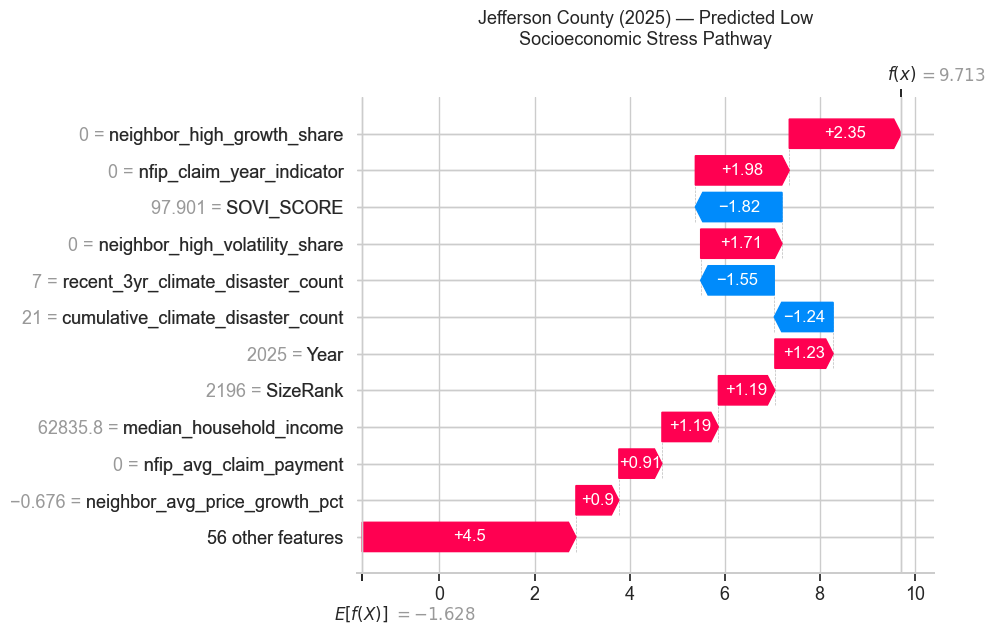

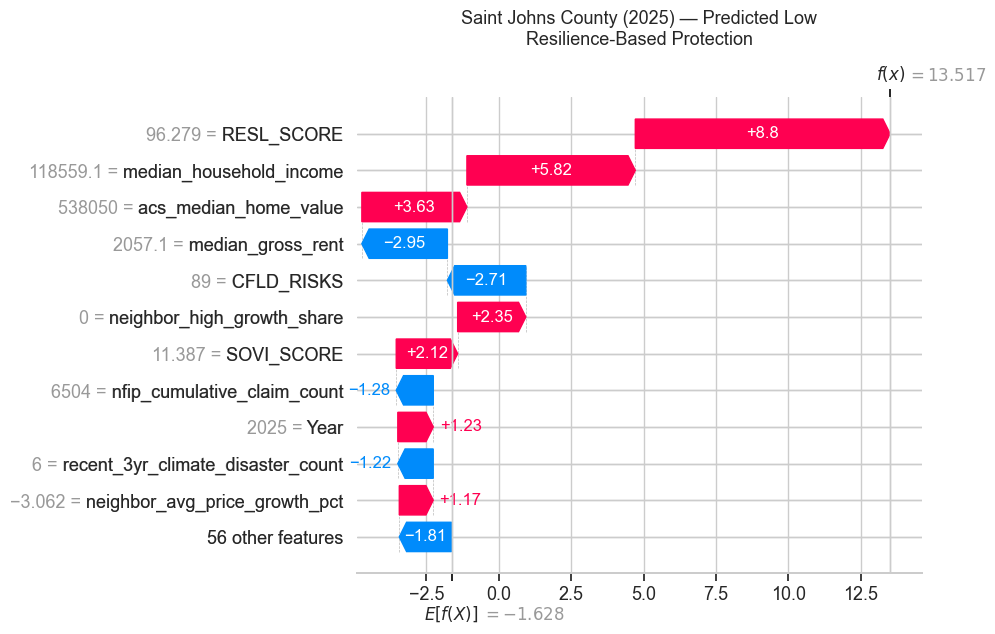

Local SHAP waterfall explanations completed.
Waterfall figures created: 4


,case_order,RegionName,Year,explained_class,figure_path
0,1,Miami-Dade County,2025,High,results/figures/shap_explainability/shap_water...
1,2,Collier County,2025,High,results/figures/shap_explainability/shap_water...
2,3,Jefferson County,2025,Low,results/figures/shap_explainability/shap_water...
3,4,Saint Johns County,2025,Low,results/figures/shap_explainability/shap_water...


,case_order,RegionName,predicted_class,local_rank,feature,feature_value,shap_value,contribution_direction
0,1,Miami-Dade County,High,1,CFLD_RISKS,99.6000,3.5669,Toward High
1,1,Miami-Dade County,High,2,neighbor_high_growth_share,0.0000,-2.7918,Away from High
2,1,Miami-Dade County,High,3,nfip_cumulative_claim_count,"9,370.0000",2.5388,Toward High
3,1,Miami-Dade County,High,4,price_to_income_ratio,6.7379,2.3731,Toward High
4,1,Miami-Dade County,High,5,acs_total_population,"2,719,757.7000",2.3728,Toward High
5,1,Miami-Dade County,High,6,median_gross_rent,"1,957.1000",2.0125,Toward High
6,1,Miami-Dade County,High,7,POPULATION,"2,698,679.0000",1.9567,Toward High
7,1,Miami-Dade County,High,8,acs_median_home_value,"502,940.0000",-1.8412,Away from High
8,1,Miami-Dade County,High,9,median_household_income,"77,220.9000",-1.6899,Away from High
9,1,Miami-Dade County,High,10,Year,"2,025.0000",-1.3680,Away from High


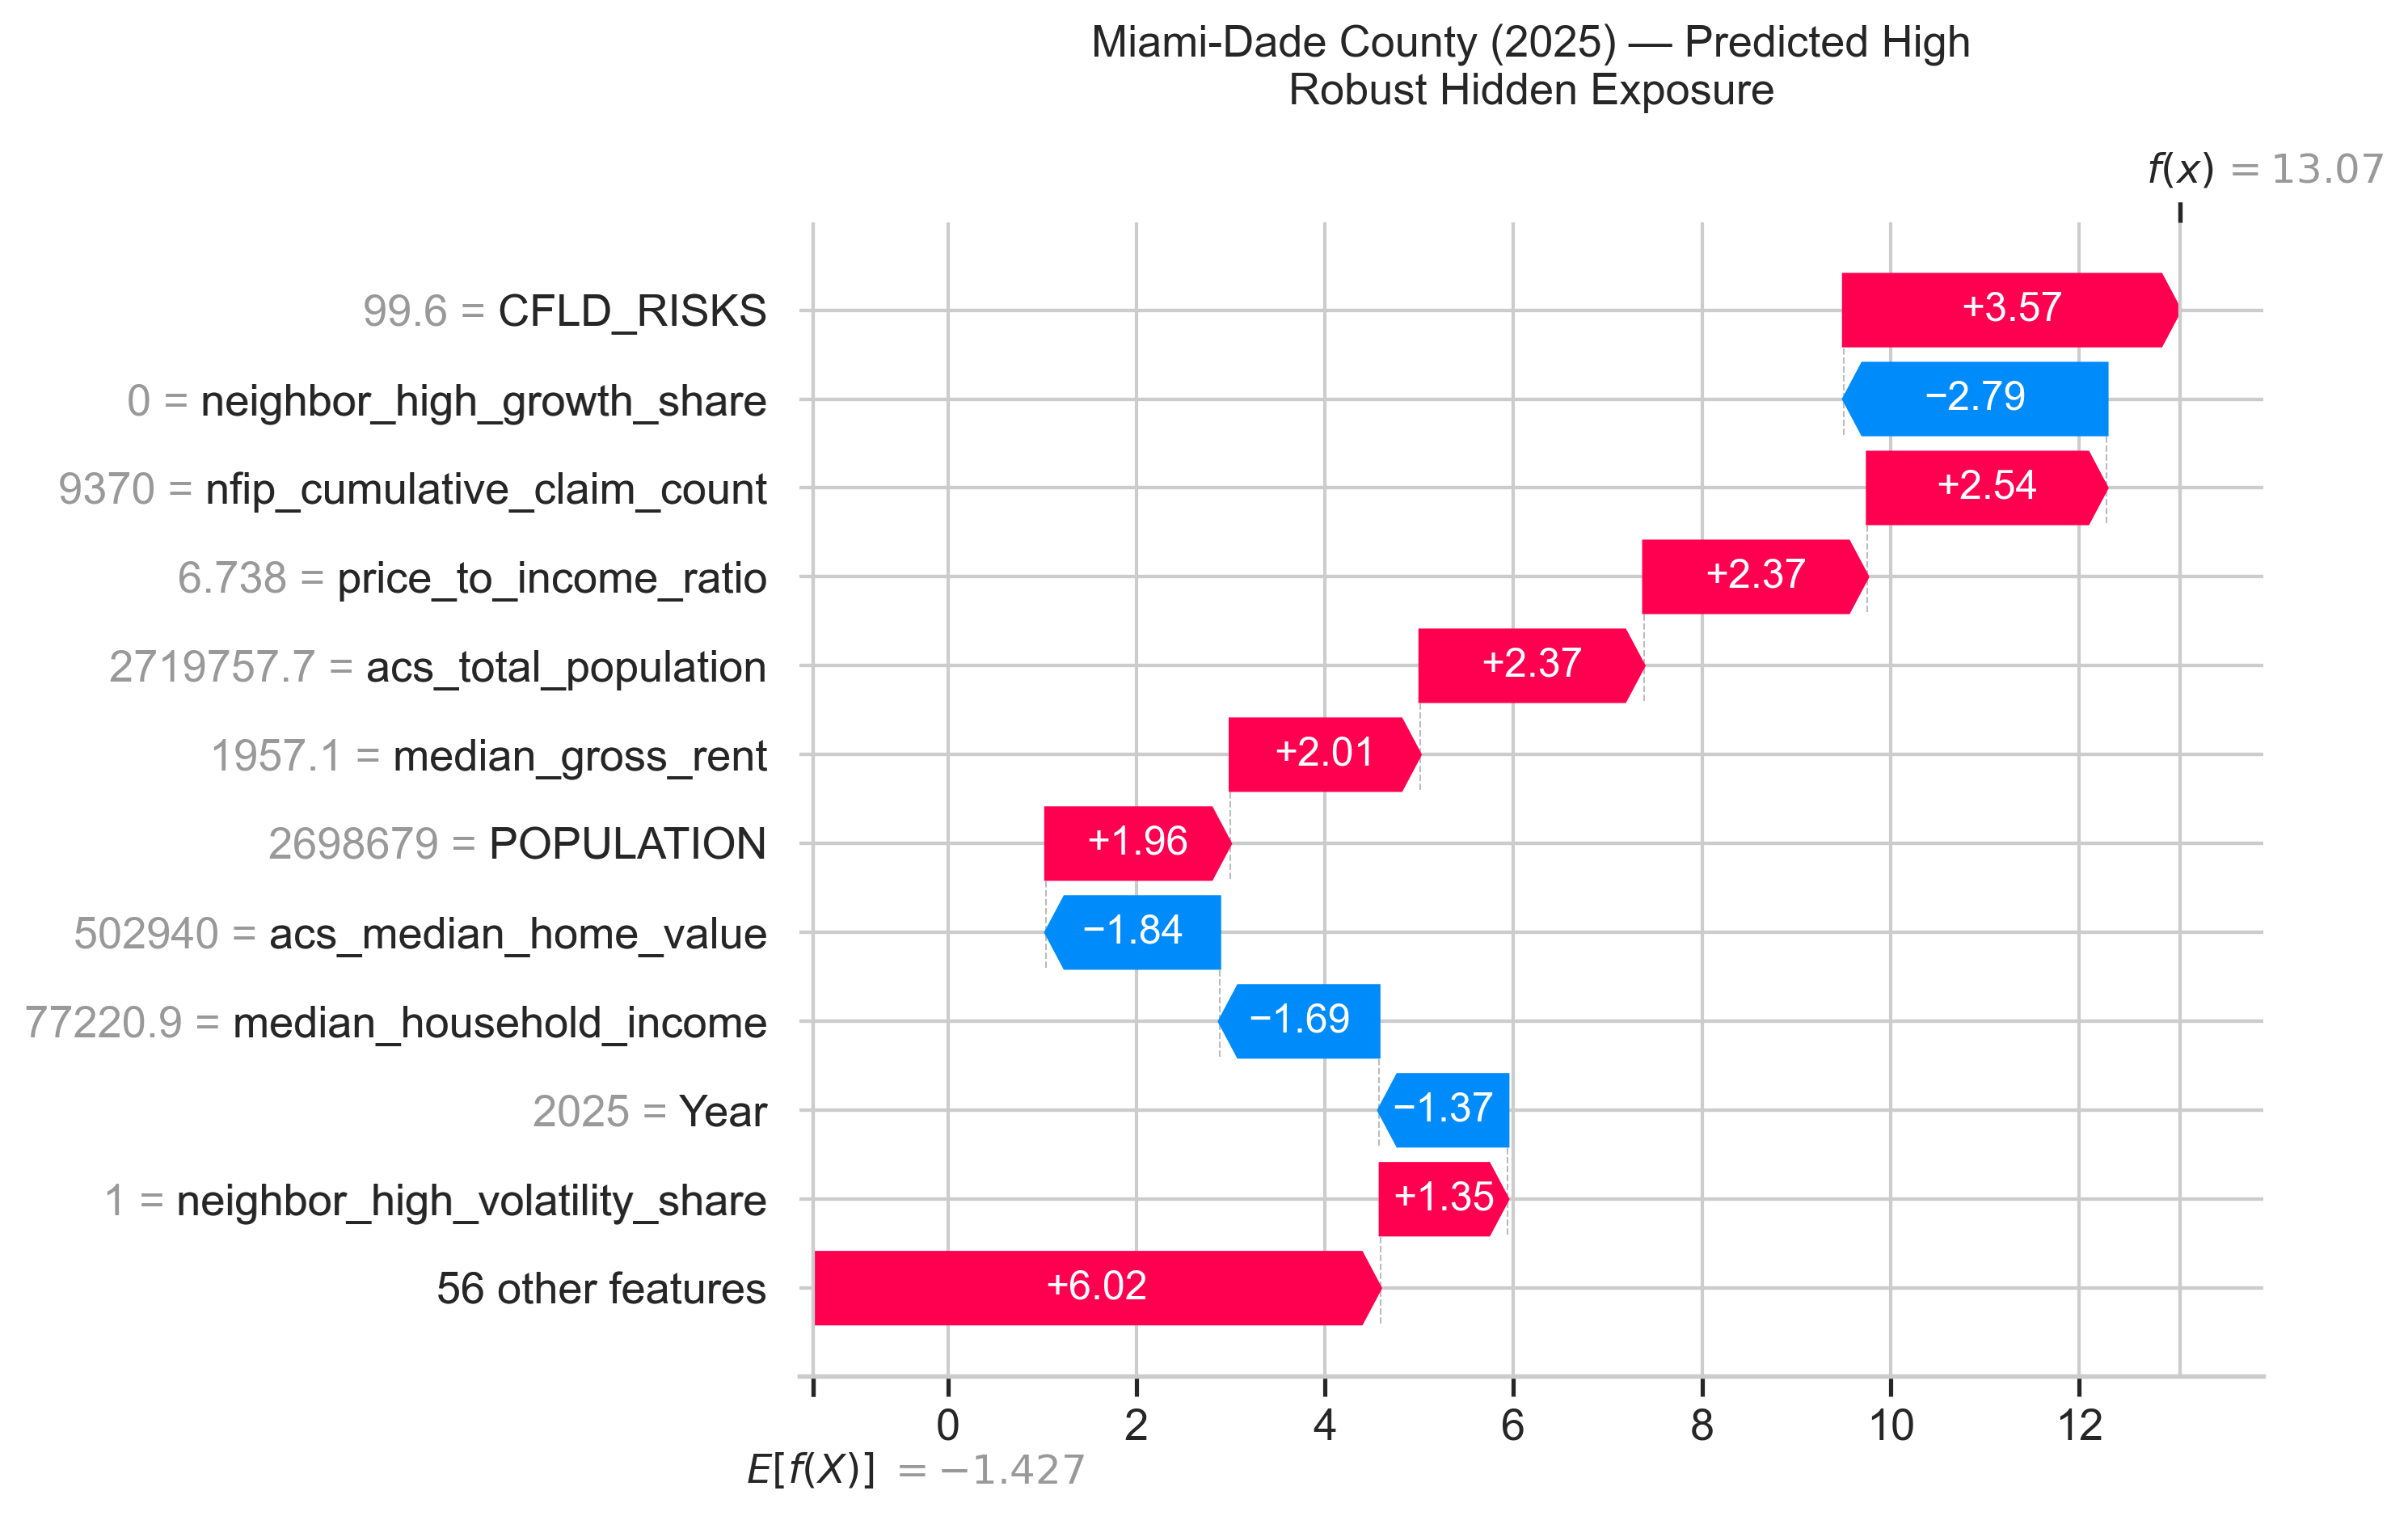

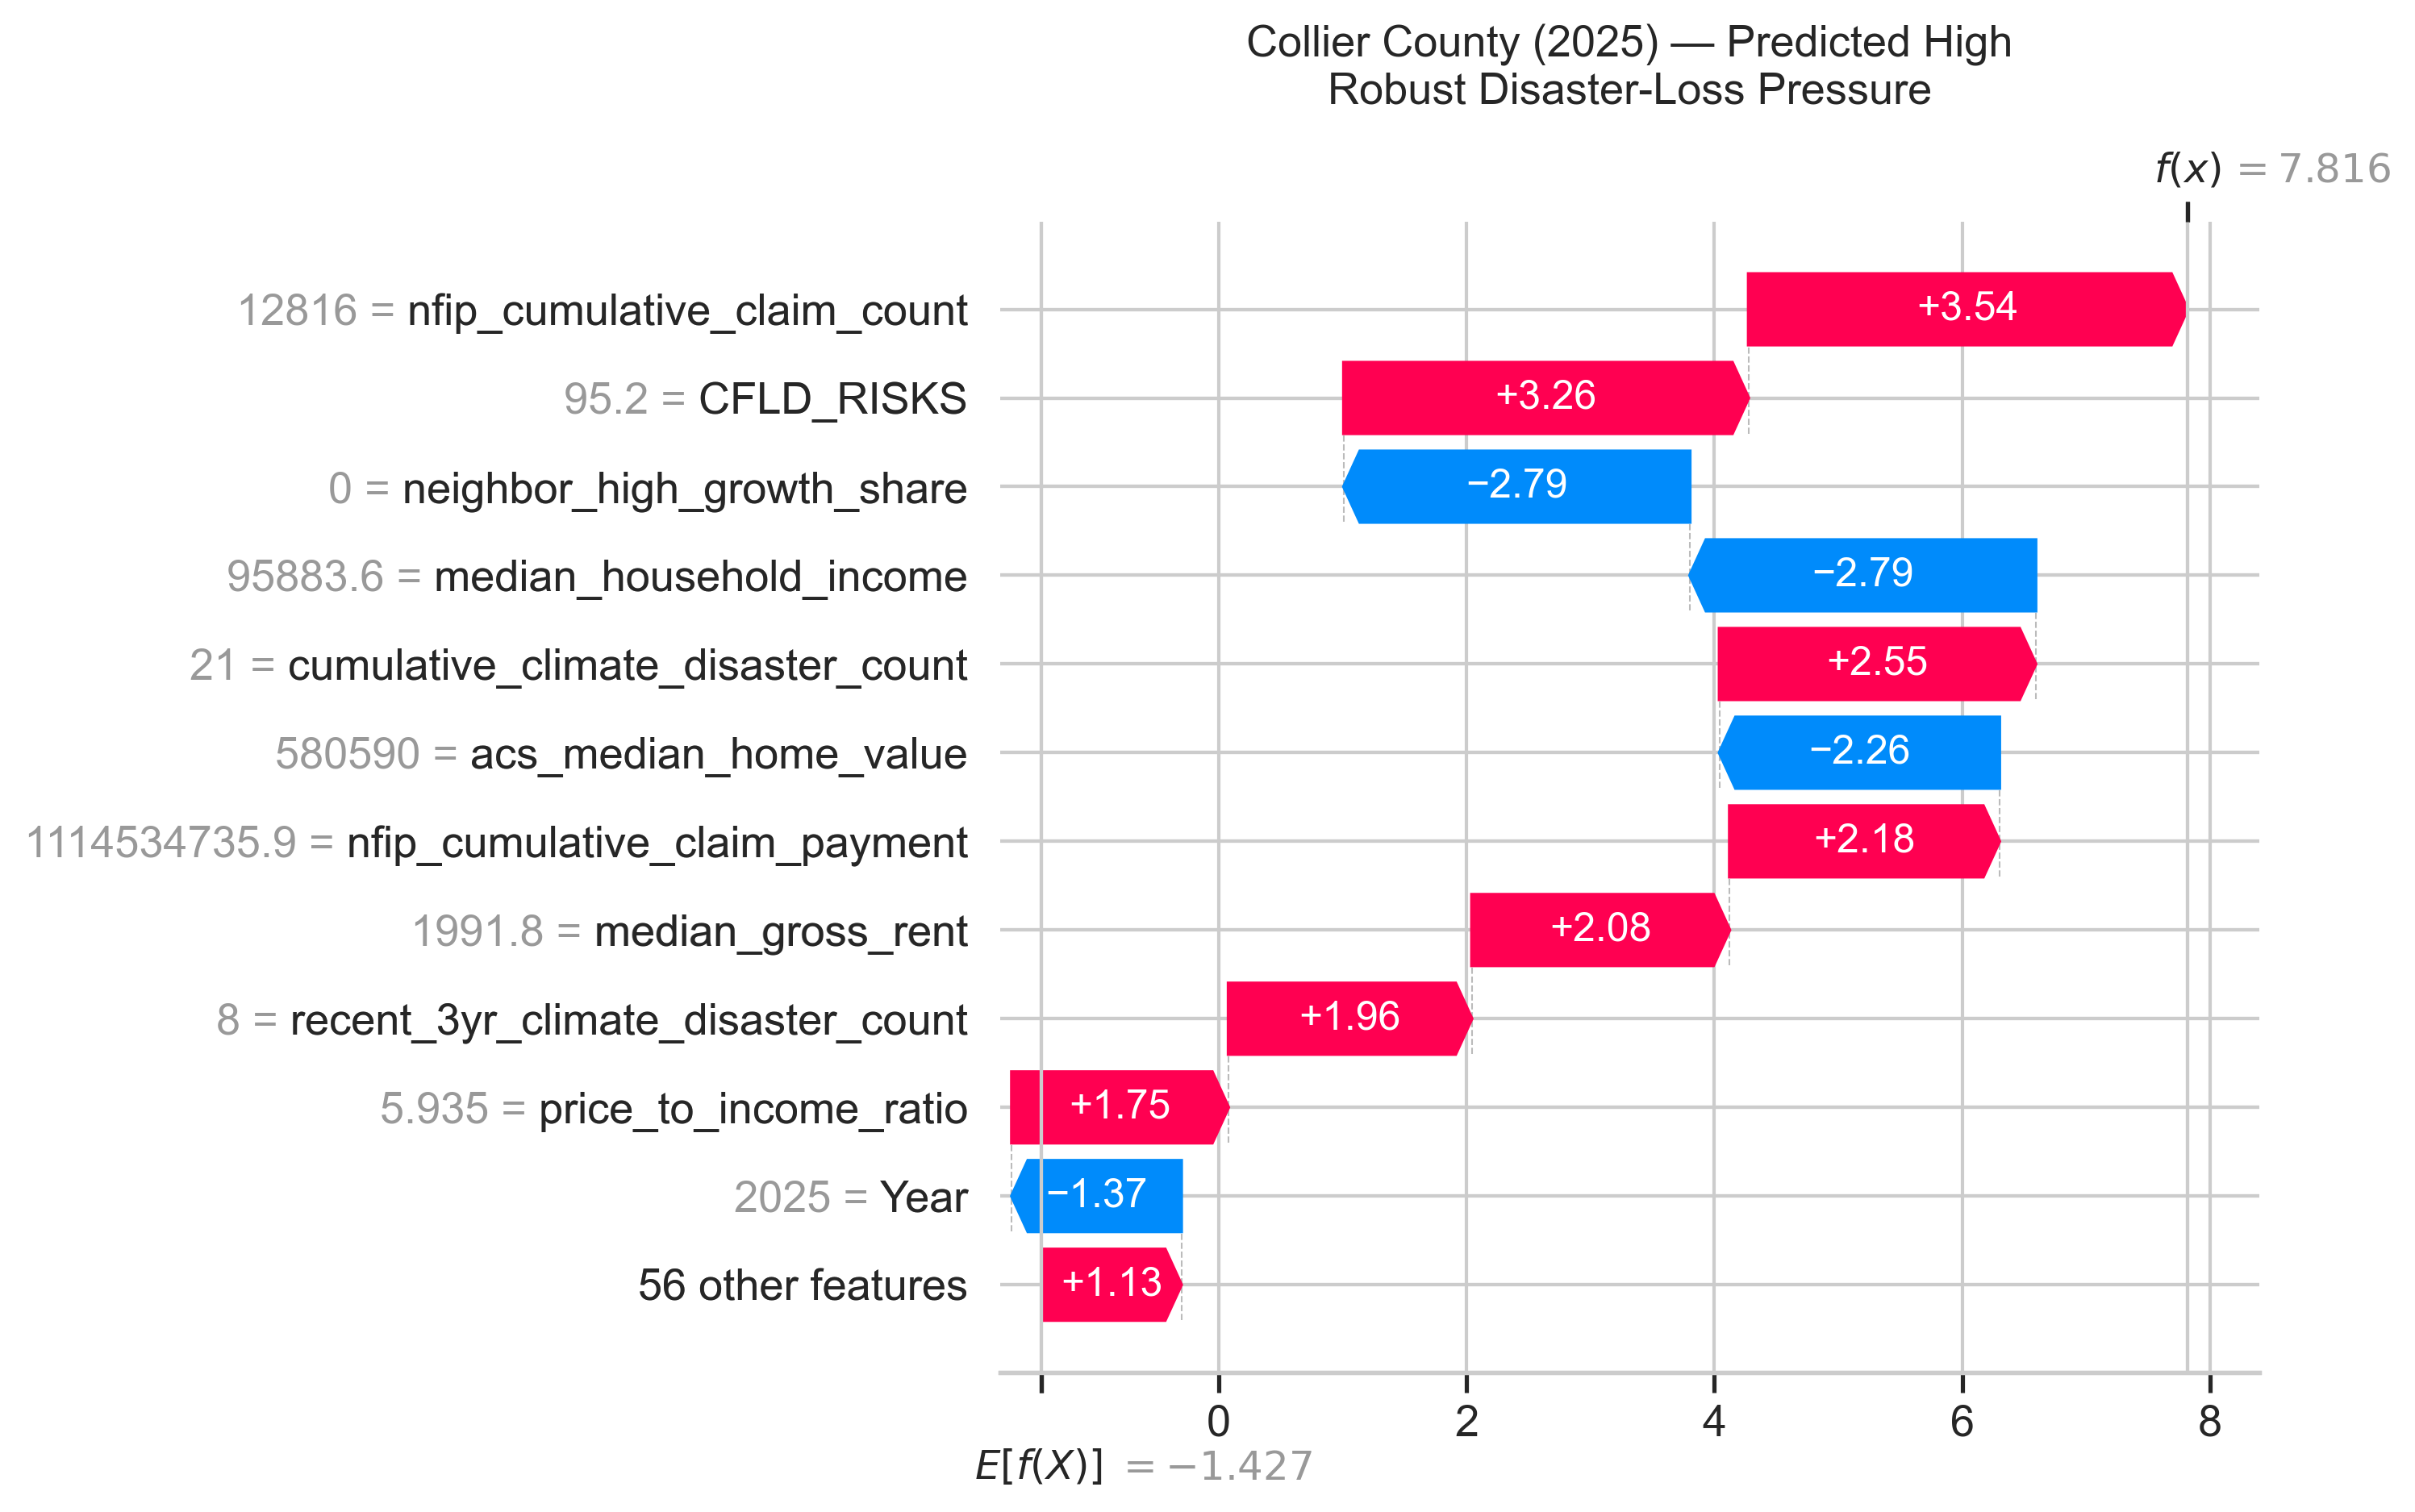

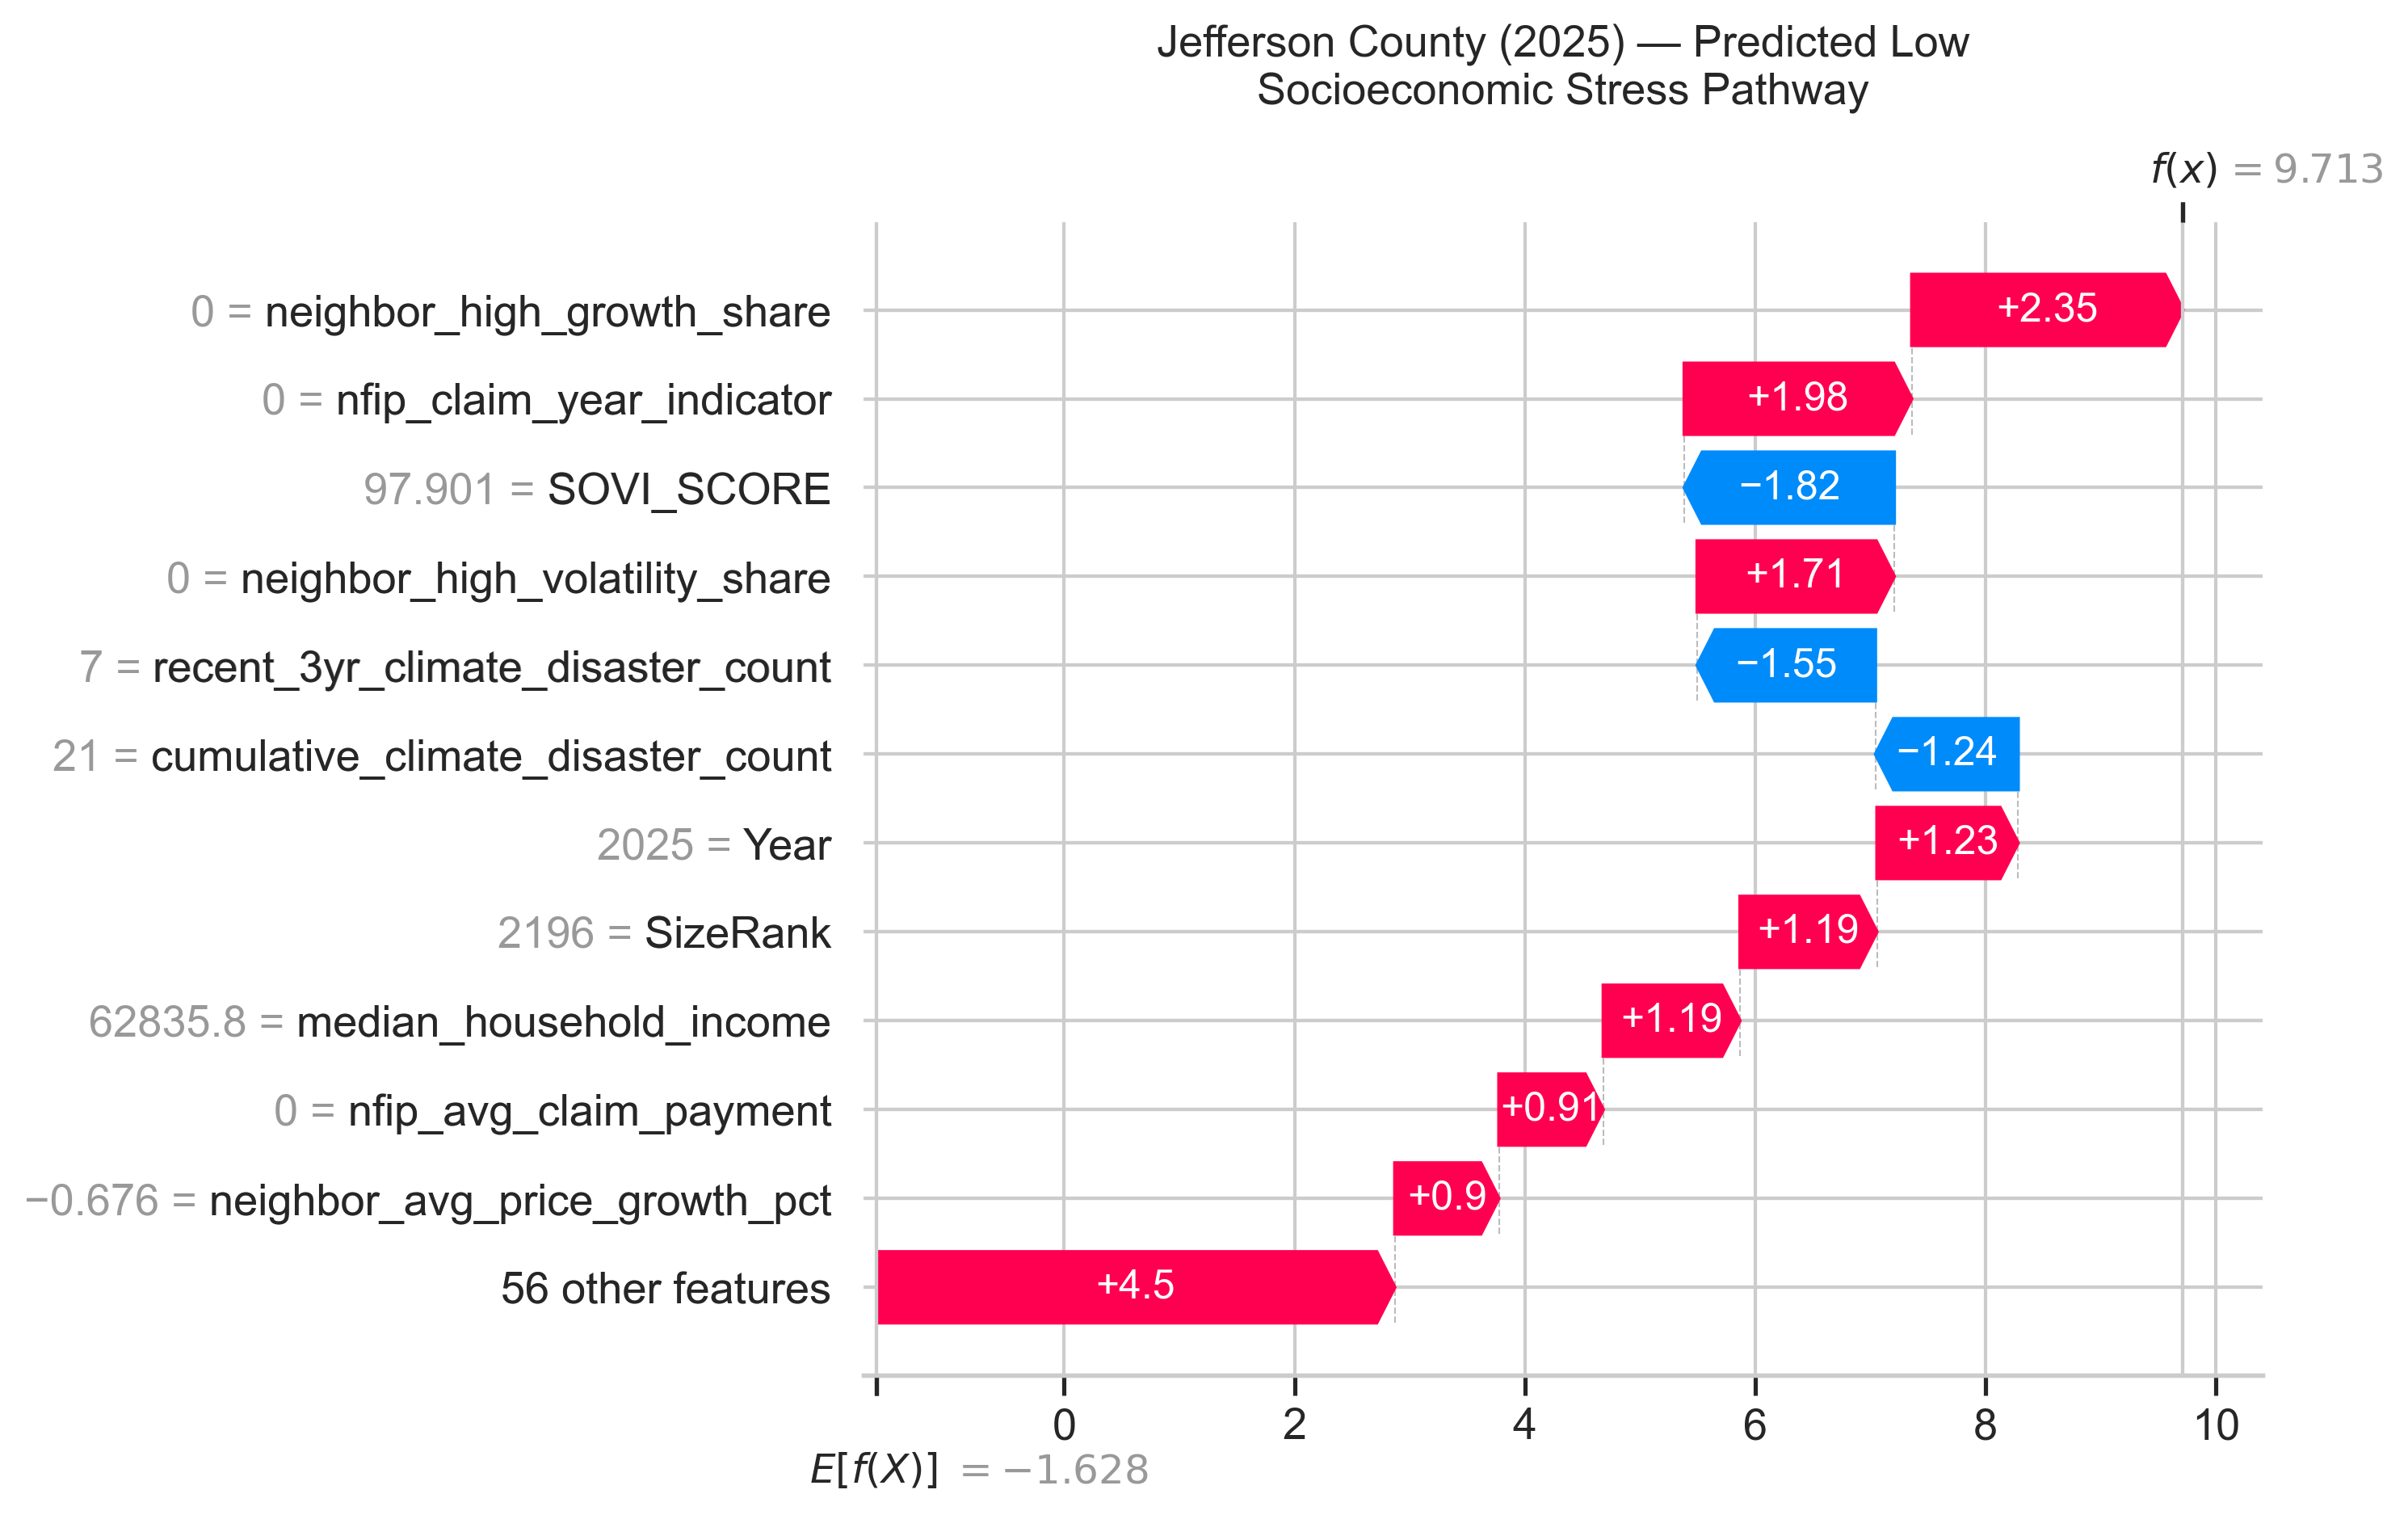

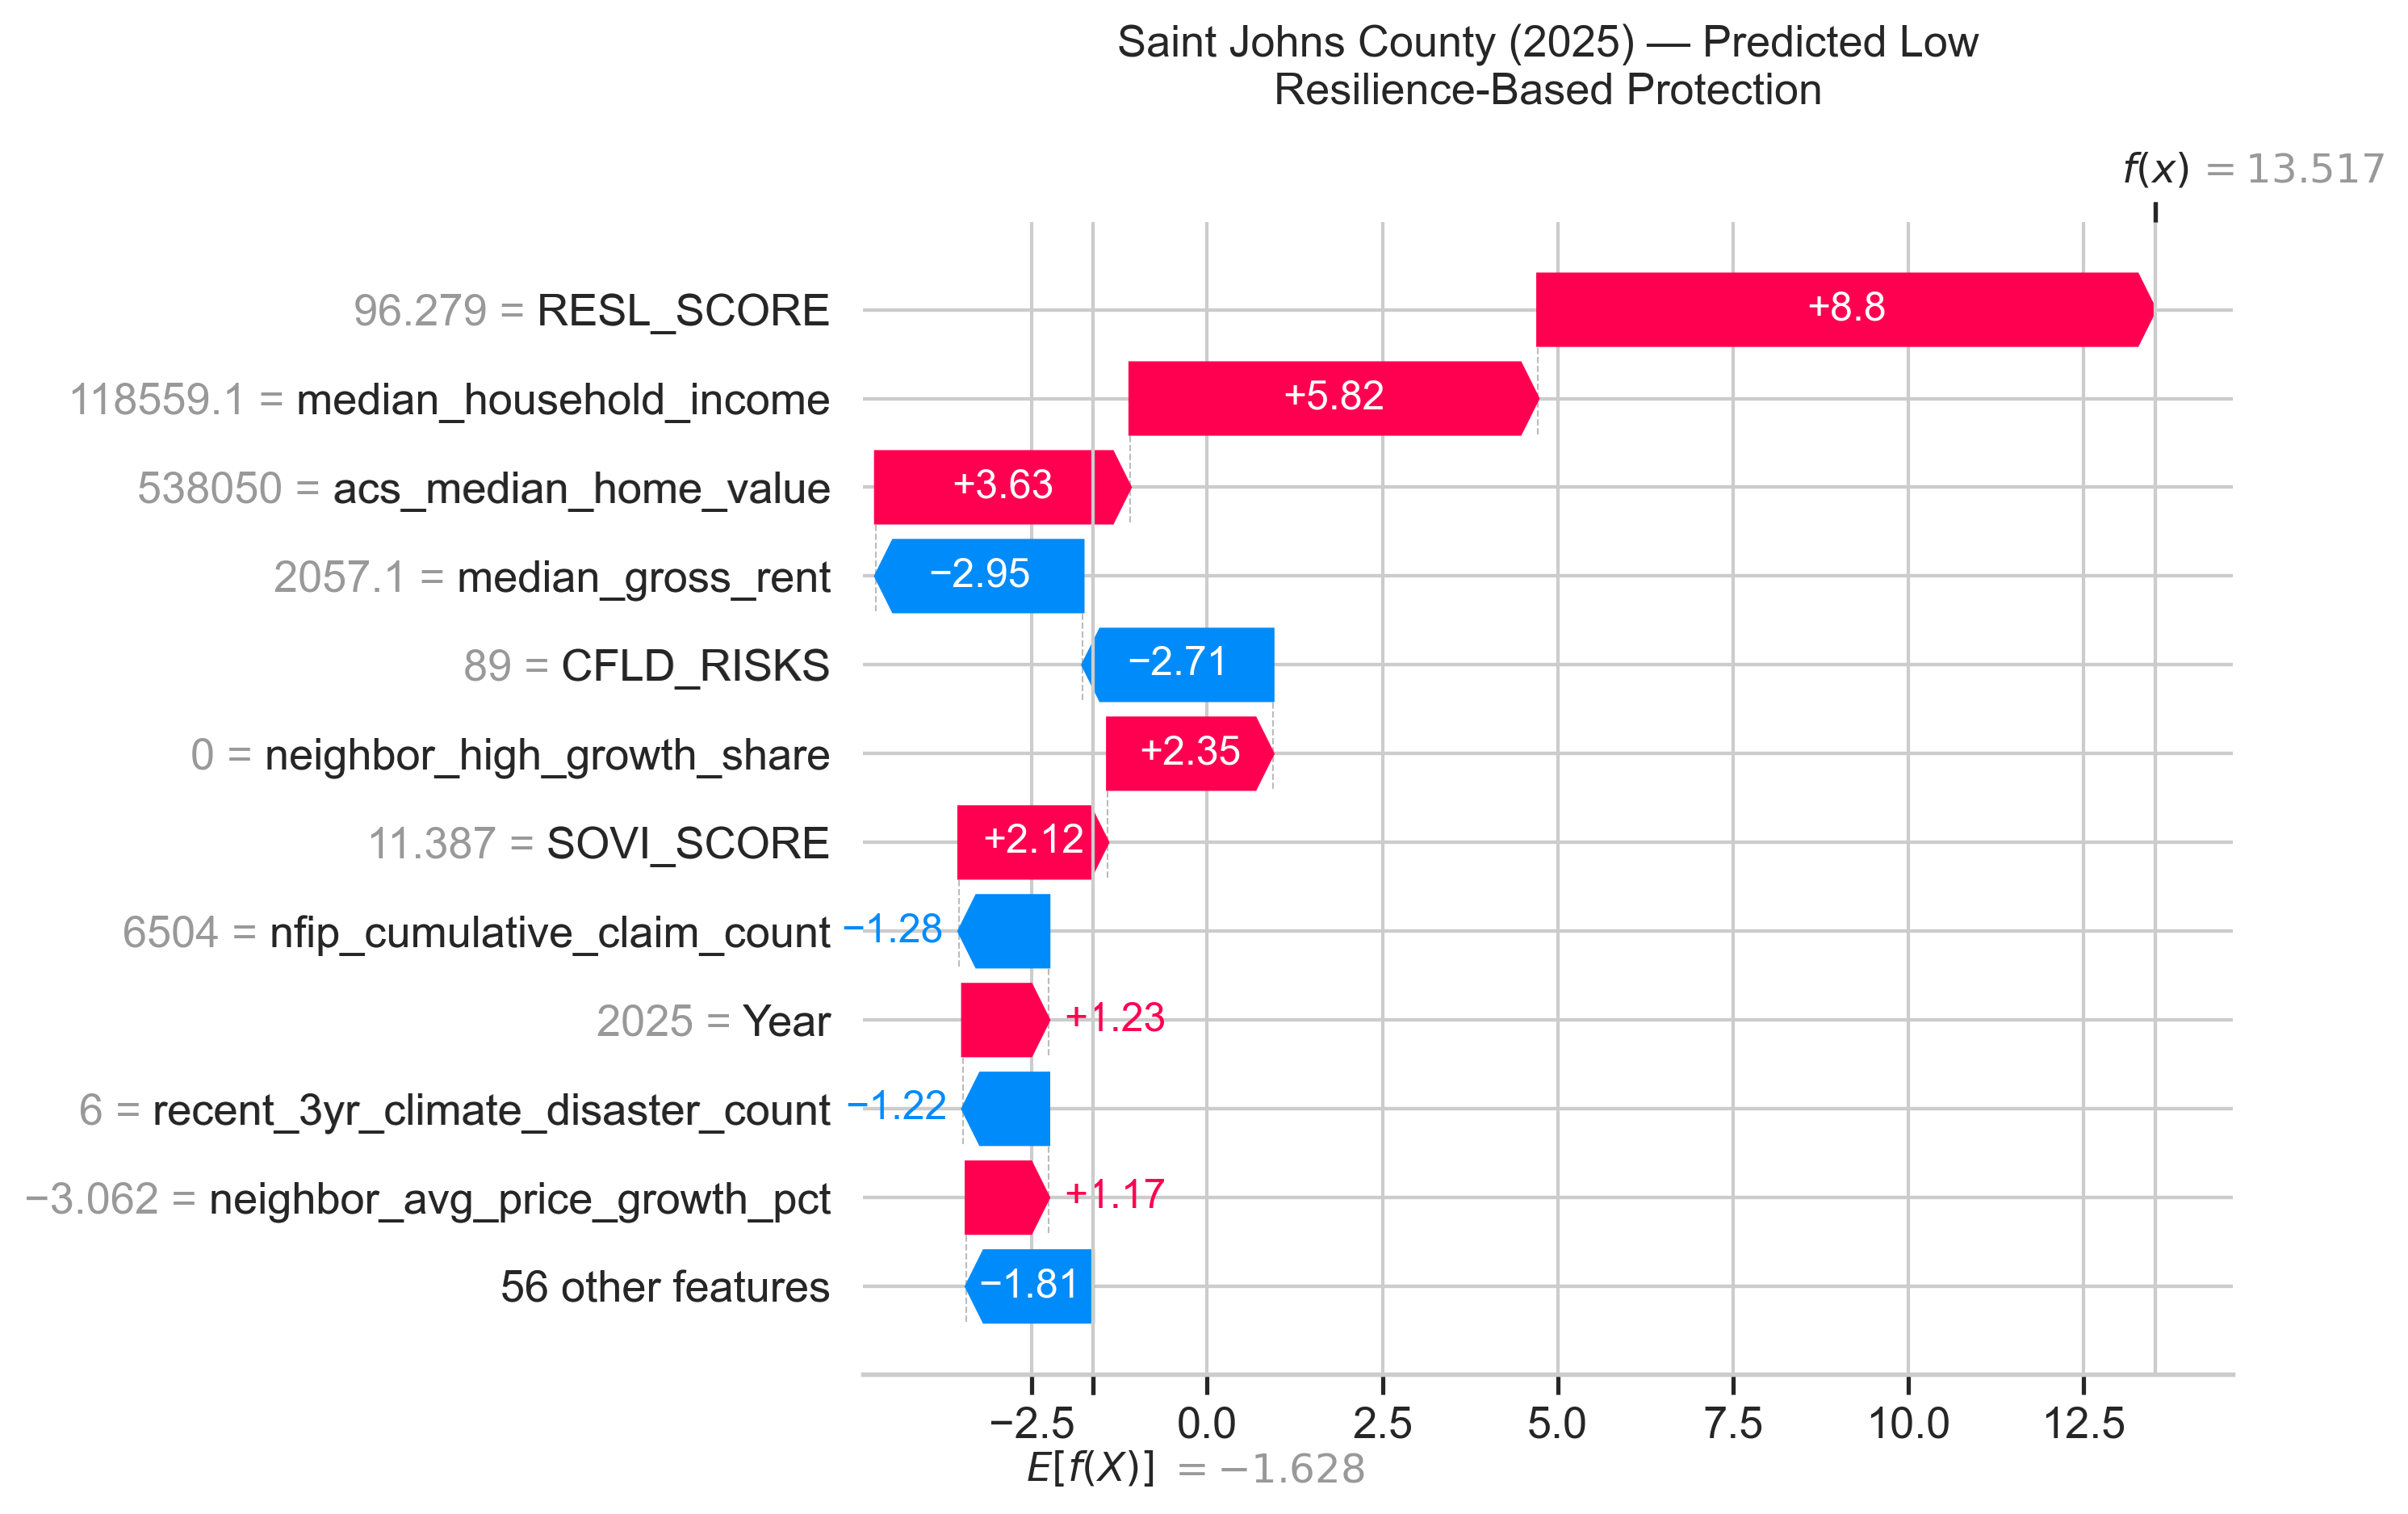

In [17]:
import re

# Create local explanations

local_shap_records = []
local_waterfall_paths = []

for _, case_row in selected_case_studies.sort_values("case_order").iterrows():

    case_mask = (explainability_data["Year"] == case_row["Year"]) & (
        explainability_data["STCOFIPS"] == case_row["STCOFIPS"]
    )

    matching_positions = np.flatnonzero(case_mask.to_numpy())

    if len(matching_positions) != 1:
        raise ValueError(
            f"Expected one matching observation for "
            f"{case_row['RegionName']} {case_row['Year']}, "
            f"but found {len(matching_positions)}."
        )

    observation_position = int(matching_positions[0])

    # Explain the class actually predicted by the model.
    explained_class = case_row["predicted_vulnerability_class"]

    class_index = model_classes.index(explained_class)

    local_shap_values = shap_values_array[observation_position, :, class_index]

    local_base_value = base_values_matrix[observation_position, class_index]

    # Use original feature values for readable display.
    original_feature_values = X_test.iloc[observation_position].to_numpy()

    local_explanation = shap.Explanation(
        values=local_shap_values,
        base_values=local_base_value,
        data=original_feature_values,
        feature_names=readable_feature_names,
    )

    # Waterfall plot

    shap.plots.waterfall(local_explanation, max_display=12, show=False)

    figure = plt.gcf()
    figure.set_size_inches(10, 6.5)

    plt.title(
        (
            f"{case_row['RegionName']} ({int(case_row['Year'])}) — "
            f"Predicted {explained_class}\n"
            f"{case_row['case_label']}"
        ),
        fontsize=13,
        pad=14,
    )

    plt.tight_layout()

    safe_county_name = (
        re.sub(r"[^A-Za-z0-9]+", "_", case_row["RegionName"]).strip("_").lower()
    )

    waterfall_path = RESULTS_FIGURES / (
        f"shap_waterfall_{int(case_row['case_order'])}_"
        f"{safe_county_name}_{int(case_row['Year'])}.png"
    )

    plt.savefig(waterfall_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(figure)

    local_waterfall_paths.append(
        {
            "case_order": int(case_row["case_order"]),
            "RegionName": case_row["RegionName"],
            "Year": int(case_row["Year"]),
            "explained_class": explained_class,
            "figure_path": waterfall_path.relative_to(PROJECT_ROOT).as_posix(),
        }
    )

    # Store leading local contributions

    local_contribution_table = pd.DataFrame(
        {
            "feature": readable_feature_names,
            "feature_value": original_feature_values,
            "shap_value": local_shap_values,
        }
    )

    local_contribution_table["absolute_shap_value"] = local_contribution_table[
        "shap_value"
    ].abs()

    local_contribution_table["contribution_direction"] = np.where(
        local_contribution_table["shap_value"] > 0,
        f"Toward {explained_class}",
        f"Away from {explained_class}",
    )

    local_contribution_table = (
        local_contribution_table.sort_values("absolute_shap_value", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    for rank, contribution_row in local_contribution_table.iterrows():
        local_shap_records.append(
            {
                "case_order": int(case_row["case_order"]),
                "case_label": case_row["case_label"],
                "RegionName": case_row["RegionName"],
                "Year": int(case_row["Year"]),
                "actual_class": (case_row["actual_vulnerability_class"]),
                "predicted_class": explained_class,
                "predicted_probability": (case_row["predicted_probability"]),
                "cluster_name": case_row["cluster_name"],
                "local_rank": rank + 1,
                "feature": contribution_row["feature"],
                "feature_value": contribution_row["feature_value"],
                "shap_value": contribution_row["shap_value"],
                "absolute_shap_value": contribution_row["absolute_shap_value"],
                "contribution_direction": contribution_row["contribution_direction"],
            }
        )

# Combine local explanation outputs

local_shap_contributions = pd.DataFrame(local_shap_records)

local_waterfall_inventory = pd.DataFrame(local_waterfall_paths)

print("Local SHAP waterfall explanations completed.")
print(f"Waterfall figures created: " f"{len(local_waterfall_inventory)}")

display(local_waterfall_inventory)

display(
    local_shap_contributions[
        [
            "case_order",
            "RegionName",
            "predicted_class",
            "local_rank",
            "feature",
            "feature_value",
            "shap_value",
            "contribution_direction",
        ]
    ]
)

for relative_path in local_waterfall_inventory["figure_path"]:
    display(Image(filename=str(PROJECT_ROOT / relative_path), width=850))


## 7. Priority hidden-risk and cross-method synthesis

Explain the six priority hidden-risk counties and integrate the coefficient, feature-group, cluster-profile, and SHAP results. Annual class, profile membership, and hidden-risk status remain distinct outputs with different definitions and time horizons.


In [18]:
priority_county_names = [
    "Hernando County",
    "Collier County",
    "Monroe County",
    "Miami-Dade County",
    "Dixie County",
    "Levy County",
]

priority_county_cases = latest_case_enriched[
    latest_case_enriched["RegionName"].isin(priority_county_names)
].copy()

if len(priority_county_cases) != 6:
    raise ValueError(
        "Expected six priority hidden-risk county observations, "
        f"but found {len(priority_county_cases)}."
    )

priority_explanation_records = []

for _, county_row in priority_county_cases.iterrows():

    observation_mask = (explainability_data["Year"] == county_row["Year"]) & (
        explainability_data["STCOFIPS"] == county_row["STCOFIPS"]
    )

    observation_positions = np.flatnonzero(observation_mask.to_numpy())

    if len(observation_positions) != 1:
        raise ValueError(
            f"Expected one observation for " f"{county_row['RegionName']}."
        )

    observation_position = int(observation_positions[0])

    predicted_class = county_row["predicted_vulnerability_class"]

    predicted_class_index = model_classes.index(predicted_class)

    predicted_class_shap = pd.DataFrame(
        {
            "feature": readable_feature_names,
            "shap_value": shap_values_array[
                observation_position, :, predicted_class_index
            ],
        }
    )

    predicted_class_shap["absolute_shap_value"] = predicted_class_shap[
        "shap_value"
    ].abs()

    predicted_positive_drivers = (
        predicted_class_shap[predicted_class_shap["shap_value"] > 0]
        .sort_values("shap_value", ascending=False)
        .head(3)
    )

    predicted_negative_drivers = (
        predicted_class_shap[predicted_class_shap["shap_value"] < 0]
        .sort_values("shap_value", ascending=True)
        .head(1)
    )

    leading_predicted_class_drivers = "; ".join(
        [
            f"{row.feature} ({row.shap_value:+.2f})"
            for row in predicted_positive_drivers.itertuples()
        ]
    )

    if len(predicted_negative_drivers) > 0:
        strongest_counterforce = (
            f"{predicted_negative_drivers.iloc[0]['feature']} "
            f"({predicted_negative_drivers.iloc[0]['shap_value']:+.2f})"
        )
    else:
        strongest_counterforce = "None"

    # For counties not predicted High, retain their strongest
    # positive High-class pressures as supporting context.
    if predicted_class != "High":

        high_class_index = model_classes.index("High")

        high_class_shap = pd.DataFrame(
            {
                "feature": readable_feature_names,
                "shap_value": shap_values_array[
                    observation_position, :, high_class_index
                ],
            }
        )

        high_pressures = (
            high_class_shap[high_class_shap["shap_value"] > 0]
            .sort_values("shap_value", ascending=False)
            .head(2)
        )

        leading_high_class_pressures = "; ".join(
            [
                f"{row.feature} ({row.shap_value:+.2f})"
                for row in high_pressures.itertuples()
            ]
        )

    else:
        leading_high_class_pressures = "Same as predicted-class drivers"

    priority_explanation_records.append(
        {
            "RegionName": county_row["RegionName"],
            "Year": int(county_row["Year"]),
            "actual_class": (county_row["actual_vulnerability_class"]),
            "predicted_class": predicted_class,
            "predicted_probability": (county_row["predicted_probability"]),
            "probability_high": (county_row["probability_high"]),
            "cluster_name": county_row["cluster_name"],
            "recent_avg_annual_growth_pct": (
                county_row["recent_avg_annual_growth_pct"]
            ),
            "annual_price_growth_pct": (county_row["annual_price_growth_pct"]),
            "scenarios_selected": int(county_row["scenarios_selected"]),
            "selection_rate_pct": (county_row["selection_rate_pct"]),
            "leading_predicted_class_drivers": (leading_predicted_class_drivers),
            "strongest_counterforce": (strongest_counterforce),
            "leading_high_class_pressures": (leading_high_class_pressures),
        }
    )

priority_hidden_risk_explanations = pd.DataFrame(priority_explanation_records)

priority_hidden_risk_explanations["county_order"] = pd.Categorical(
    priority_hidden_risk_explanations["RegionName"],
    categories=priority_county_names,
    ordered=True,
)

priority_hidden_risk_explanations = (
    priority_hidden_risk_explanations.sort_values("county_order")
    .drop(columns="county_order")
    .reset_index(drop=True)
)

print("Priority hidden-risk county explanations completed.")

display(priority_hidden_risk_explanations)


Priority hidden-risk county explanations completed.


,RegionName,Year,actual_class,predicted_class,predicted_probability,probability_high,cluster_name,recent_avg_annual_growth_pct,annual_price_growth_pct,scenarios_selected,selection_rate_pct,leading_predicted_class_drivers,strongest_counterforce,leading_high_class_pressures
0,Hernando County,2025,Medium,High,0.8781,0.8781,Disaster-Loss Growth Pressure,10.8240,-3.1260,8,100.0000,RESL_SCORE (+3.40); cumulative_climate_disaste...,neighbor_high_growth_share (-2.79),Same as predicted-class drivers
1,Collier County,2025,High,High,0.9995,0.9995,Disaster-Loss Growth Pressure,10.5318,-6.7571,8,100.0000,nfip_cumulative_claim_count (+3.54); CFLD_RISK...,neighbor_high_growth_share (-2.79),Same as predicted-class drivers
2,Monroe County,2025,High,High,0.9800,0.9800,Disaster-Loss Growth Pressure,10.0460,-4.3833,8,100.0000,price_to_income_ratio (+5.23); CFLD_RISKS (+3....,acs_median_home_value (-3.66),Same as predicted-class drivers
3,Miami-Dade County,2025,High,High,0.9995,0.9995,High-Exposure Latent Risk,10.0276,-1.1850,8,100.0000,CFLD_RISKS (+3.57); nfip_cumulative_claim_coun...,neighbor_high_growth_share (-2.79),Same as predicted-class drivers
4,Dixie County,2025,Medium,Low,0.9745,0.0001,Socioeconomic Resilience Stress,9.8193,0.5435,7,87.5000,neighbor_high_growth_share (+2.35); nfip_claim...,RESL_SCORE (-4.10),RESL_SCORE (+3.79); cumulative_climate_disaste...
5,Levy County,2025,Medium,Low,0.8968,0.0044,Socioeconomic Resilience Stress,9.7679,-1.3703,7,87.5000,neighbor_high_growth_share (+2.35); nfip_claim...,RESL_SCORE (-3.24),RESL_SCORE (+3.00); cumulative_climate_disaste...


In [19]:
print("Overall feature-group comparison:")
display(feature_group_comparison)

print("Marginal feature-layer contribution:")
display(marginal_contribution)

print("Grouped SHAP contribution:")
display(
    grouped_shap_importance[
        [
            "group_rank",
            "feature_dimension",
            "feature_count",
            "group_contribution_pct",
            "average_shap_per_feature",
            "leading_feature",
        ]
    ]
)

# Create concise synthesis table

dimension_interpretation = {
    "Housing Pressure and Market Conditions": "Housing conditions contribute useful context but do not dominate the final classifier.",
    "Climate Exposure": "Only two exposure variables are included, but each has a strong average contribution.",
    "Disaster History": "Disaster indicators provide substantial collective information, consistent with the large performance gain when this layer was added.",
    "Socioeconomic and Affordability Stress": "This is the largest collective SHAP dimension, although its features showed less consistent temporal-validation gains.",
    "Insurance-Loss Stress": "NFIP indicators add realized-loss information beyond hazard exposure and disaster declarations.",
    "Spatial Spillover": "Neighbouring market conditions are influential despite the group containing only six variables.",
    "Resilience": "The single resilience variable has the strongest average per-feature SHAP contribution.",
}

feature_group_shap_synthesis = grouped_shap_importance[
    [
        "group_rank",
        "feature_dimension",
        "feature_count",
        "group_contribution_pct",
        "average_shap_per_feature",
        "leading_feature",
    ]
].copy()

feature_group_shap_synthesis["interpretation"] = feature_group_shap_synthesis[
    "feature_dimension"
].map(dimension_interpretation)

print("Feature-group and SHAP evidence integrated.")

display(feature_group_shap_synthesis)


Overall feature-group comparison:


,feature_group,number_of_features,cv_macro_f1_mean,cv_macro_f1_std,test_macro_f1,test_accuracy,test_macro_precision,test_macro_recall,test_weighted_f1
0,Housing Only,16,0.3784,0.1118,0.2847,0.3632,0.4526,0.3433,0.3014
1,Housing + Climate,18,0.6142,0.0683,0.4599,0.5025,0.5784,0.4741,0.4757
2,Housing + Climate + Disaster,32,0.6663,0.1120,0.6931,0.6915,0.7440,0.6901,0.6874
3,Housing + Climate + Disaster + ACS,47,0.6203,0.1424,0.7453,0.7413,0.7509,0.7575,0.7419
4,Full Model,67,0.7345,0.1097,0.7687,0.7761,0.8038,0.8077,0.7622


Marginal feature-layer contribution:


,feature_group,added_layer,number_of_features,test_macro_f1,delta_test_macro_f1,test_accuracy,delta_test_accuracy,test_weighted_f1,delta_test_weighted_f1,cv_macro_f1_mean,delta_cv_macro_f1_mean
0,Housing Only,Housing baseline,16,0.2847,NaN,0.3632,NaN,0.3014,NaN,0.3784,NaN
1,Housing + Climate,+ Climate exposure,18,0.4599,0.1752,0.5025,0.1393,0.4757,0.1743,0.6142,0.2358
2,Housing + Climate + Disaster,+ Disaster history,32,0.6931,0.2332,0.6915,0.1891,0.6874,0.2117,0.6663,0.0521
3,Housing + Climate + Disaster + ACS,+ ACS / socioeconomic / affordability,47,0.7453,0.0522,0.7413,0.0498,0.7419,0.0545,0.6203,-0.0460
4,Full Model,+ NFIP insurance-loss + spatial spillovers,67,0.7687,0.0234,0.7761,0.0348,0.7622,0.0203,0.7345,0.1142


Grouped SHAP contribution:


,group_rank,feature_dimension,feature_count,group_contribution_pct,average_shap_per_feature,leading_feature
0,1,Socioeconomic and Affordability Stress,14,23.5246,0.4218,median_household_income
1,2,Disaster History,14,20.7767,0.3725,cumulative_climate_disaster_count
2,3,Insurance-Loss Stress,14,13.6920,0.2455,nfip_avg_claim_payment
3,4,Spatial Spillover,6,13.2333,0.5536,neighbor_high_growth_share
4,5,Housing Pressure and Market Conditions,15,13.0905,0.2190,price_growth_acceleration
5,6,Climate Exposure,2,8.7541,1.0986,CFLD_RISKS
6,7,Resilience,1,6.9289,1.7391,RESL_SCORE


Feature-group and SHAP evidence integrated.


,group_rank,feature_dimension,feature_count,group_contribution_pct,average_shap_per_feature,leading_feature,interpretation
0,1,Socioeconomic and Affordability Stress,14,23.5246,0.4218,median_household_income,"This is the largest collective SHAP dimension,..."
1,2,Disaster History,14,20.7767,0.3725,cumulative_climate_disaster_count,Disaster indicators provide substantial collec...
2,3,Insurance-Loss Stress,14,13.6920,0.2455,nfip_avg_claim_payment,NFIP indicators add realized-loss information ...
3,4,Spatial Spillover,6,13.2333,0.5536,neighbor_high_growth_share,Neighbouring market conditions are influential...
4,5,Housing Pressure and Market Conditions,15,13.0905,0.2190,price_growth_acceleration,Housing conditions contribute useful context b...
5,6,Climate Exposure,2,8.7541,1.0986,CFLD_RISKS,"Only two exposure variables are included, but ..."
6,7,Resilience,1,6.9289,1.7391,RESL_SCORE,The single resilience variable has the stronge...


In [20]:
# Prepare absolute High-class SHAP values

high_class_index = model_classes.index("High")

high_shap_feature_table = pd.DataFrame(
    np.abs(shap_values_array[:, :, high_class_index]), columns=readable_feature_names
)

high_shap_feature_table[["Year", "STCOFIPS", "cluster_name"]] = explainability_data[
    ["Year", "STCOFIPS", "cluster_name"]
].reset_index(drop=True)

dimension_feature_lists = (
    feature_dimension_table[
        feature_dimension_table["feature_dimension"] != "Temporal Control"
    ]
    .groupby("feature_dimension")["feature"]
    .apply(list)
    .to_dict()
)

# Calculate total and per-feature SHAP contributions

dimension_records = []

for cluster_name, cluster_data in high_shap_feature_table.groupby("cluster_name"):

    for dimension_name, dimension_features in dimension_feature_lists.items():

        dimension_values = cluster_data[dimension_features]

        dimension_records.append(
            {
                "cluster_name": cluster_name,
                "feature_dimension": dimension_name,
                "feature_count": len(dimension_features),
                "mean_total_absolute_high_shap": (dimension_values.sum(axis=1).mean()),
                "mean_absolute_high_shap_per_feature": (
                    dimension_values.mean(axis=1).mean()
                ),
            }
        )

cluster_dimension_long = pd.DataFrame(dimension_records)

# Rank using per-feature contribution so that dimensions
# with more variables do not automatically rank higher.
cluster_dimension_long["dimension_rank"] = cluster_dimension_long.groupby(
    "cluster_name"
)["mean_absolute_high_shap_per_feature"].rank(method="first", ascending=False)

# Summarize classification outcomes by cluster

cluster_class_summary = explainability_data.groupby("cluster_name", as_index=False).agg(
    observations=("STCOFIPS", "size"),
    mean_probability_high=("probability_high", "mean"),
    prediction_accuracy=("prediction_correct", "mean"),
    mean_annual_growth_pct=("annual_price_growth_pct", "mean"),
)

cluster_class_summary["prediction_accuracy_pct"] = (
    cluster_class_summary["prediction_accuracy"] * 100
)

# Calculate actual-class composition

actual_class_composition = (
    explainability_data.groupby(["cluster_name", "actual_vulnerability_class"])
    .size()
    .reset_index(name="observations")
)

actual_class_composition["cluster_total"] = actual_class_composition.groupby(
    "cluster_name"
)["observations"].transform("sum")

actual_class_composition["actual_class_pct"] = (
    actual_class_composition["observations"]
    / actual_class_composition["cluster_total"]
    * 100
)

actual_class_pivot = (
    actual_class_composition.pivot(
        index="cluster_name",
        columns="actual_vulnerability_class",
        values="actual_class_pct",
    )
    .fillna(0)
    .reset_index()
)

actual_class_pivot.columns.name = None

actual_class_pivot = actual_class_pivot.rename(
    columns={
        "Low": "actual_low_pct",
        "Medium": "actual_medium_pct",
        "High": "actual_high_pct",
    }
)

# Identify top two dimensions per cluster

top_cluster_dimensions = (
    cluster_dimension_long[cluster_dimension_long["dimension_rank"] <= 2]
    .sort_values(["cluster_name", "dimension_rank"])
    .groupby("cluster_name", as_index=False)
    .apply(
        lambda group: pd.Series(
            {
                "leading_high_class_dimensions": "; ".join(
                    [
                        (
                            f"{row.feature_dimension} "
                            f"({row.mean_absolute_high_shap_per_feature:.2f})"
                        )
                        for row in group.itertuples()
                    ]
                )
            }
        ),
        include_groups=False,
    )
)

# Build final synthesis table

class_cluster_shap_synthesis = cluster_class_summary.merge(
    actual_class_pivot, on="cluster_name", how="left", validate="one_to_one"
).merge(top_cluster_dimensions, on="cluster_name", how="left", validate="one_to_one")

profile_interpretation = {
    "Lower-Stress Resilient Profile": "Generally lower severity, with resilience and lower multidimensional pressure limiting High-vulnerability predictions.",
    "Disaster-Loss Growth Pressure": "Frequently High vulnerability, combining strong-market conditions with accumulated disaster and insurance-loss pressure.",
    "High-Exposure Latent Risk": "Exposure-led and transitional, with structural climate pressure that may not always be accompanied by realized losses.",
    "Socioeconomic Resilience Stress": "Socially stressed pathway whose overall class depends on whether climate, disaster, insurance, and spatial pressures are also present.",
}

class_cluster_shap_synthesis["profile_interpretation"] = class_cluster_shap_synthesis[
    "cluster_name"
].map(profile_interpretation)

profile_order = [
    "Lower-Stress Resilient Profile",
    "Disaster-Loss Growth Pressure",
    "High-Exposure Latent Risk",
    "Socioeconomic Resilience Stress",
]

class_cluster_shap_synthesis["profile_order"] = pd.Categorical(
    class_cluster_shap_synthesis["cluster_name"], categories=profile_order, ordered=True
)

class_cluster_shap_synthesis = (
    class_cluster_shap_synthesis.sort_values("profile_order")
    .drop(columns=["prediction_accuracy", "profile_order"])
    .reset_index(drop=True)
)

print(
    "Classification, clustering, and normalized "
    "SHAP evidence integrated successfully."
)

display(class_cluster_shap_synthesis)

print("Complete cluster-dimension SHAP table:")
display(cluster_dimension_long.sort_values(["cluster_name", "dimension_rank"]))


Classification, clustering, and normalized SHAP evidence integrated successfully.


,cluster_name,observations,mean_probability_high,mean_annual_growth_pct,prediction_accuracy_pct,actual_high_pct,actual_low_pct,actual_medium_pct,leading_high_class_dimensions,profile_interpretation
0,Lower-Stress Resilient Profile,37,0.0035,-0.1942,70.2703,0.0000,64.8649,35.1351,Resilience (3.59); Climate Exposure (1.50),"Generally lower severity, with resilience and ..."
1,Disaster-Loss Growth Pressure,92,0.6749,1.0532,84.7826,61.9565,1.0870,36.9565,Resilience (2.16); Climate Exposure (1.68),"Frequently High vulnerability, combining stron..."
2,High-Exposure Latent Risk,13,0.5999,-0.7777,61.5385,61.5385,0.0000,38.4615,Climate Exposure (1.75); Resilience (1.52),"Exposure-led and transitional, with structural..."
3,Socioeconomic Resilience Stress,59,0.0558,2.6955,74.5763,6.7797,47.4576,45.7627,Resilience (2.27); Climate Exposure (1.66),Socially stressed pathway whose overall class ...


Complete cluster-dimension SHAP table:


,cluster_name,feature_dimension,feature_count,mean_total_absolute_high_shap,mean_absolute_high_shap_per_feature,dimension_rank
4,Disaster-Loss Growth Pressure,Resilience,1,2.1573,2.1573,1.0000
0,Disaster-Loss Growth Pressure,Climate Exposure,2,3.3635,1.6817,2.0000
6,Disaster-Loss Growth Pressure,Spatial Spillover,6,4.2744,0.7124,3.0000
1,Disaster-Loss Growth Pressure,Disaster History,14,7.9724,0.5695,4.0000
5,Disaster-Loss Growth Pressure,Socioeconomic and Affordability Stress,14,7.3972,0.5284,5.0000
3,Disaster-Loss Growth Pressure,Insurance-Loss Stress,14,7.0822,0.5059,6.0000
2,Disaster-Loss Growth Pressure,Housing Pressure and Market Conditions,15,4.0050,0.2670,7.0000
7,High-Exposure Latent Risk,Climate Exposure,2,3.4914,1.7457,1.0000
11,High-Exposure Latent Risk,Resilience,1,1.5194,1.5194,2.0000
13,High-Exposure Latent Risk,Spatial Spillover,6,4.6529,0.7755,3.0000


In [21]:
# Prepare signed High-class SHAP values

signed_high_shap_table = pd.DataFrame(
    shap_values_array[:, :, high_class_index], columns=readable_feature_names
)

signed_high_shap_table["cluster_name"] = explainability_data[
    "cluster_name"
].reset_index(drop=True)

directional_dimension_records = []

for cluster_name, cluster_data in signed_high_shap_table.groupby("cluster_name"):

    for dimension_name, dimension_features in dimension_feature_lists.items():

        dimension_values = cluster_data[dimension_features].to_numpy()

        directional_dimension_records.append(
            {
                "cluster_name": cluster_name,
                "feature_dimension": dimension_name,
                "feature_count": len(dimension_features),
                # Net direction after combining all features
                "mean_total_signed_high_shap": (dimension_values.sum(axis=1).mean()),
                # Normalized directional effect
                "mean_signed_high_shap_per_feature": (dimension_values.mean()),
                # Positive and negative contributions retained separately
                "mean_positive_high_shap_per_feature": (
                    np.clip(dimension_values, a_min=0, a_max=None).mean()
                ),
                "mean_negative_high_shap_per_feature": (
                    np.clip(dimension_values, a_min=None, a_max=0).mean()
                ),
            }
        )

cluster_dimension_direction = pd.DataFrame(directional_dimension_records)

# Identify strongest net push toward and away from High

cluster_direction_summary_records = []

for cluster_name, cluster_data in cluster_dimension_direction.groupby("cluster_name"):

    toward_high = (
        cluster_data[cluster_data["mean_signed_high_shap_per_feature"] > 0]
        .sort_values("mean_signed_high_shap_per_feature", ascending=False)
        .head(1)
    )

    away_from_high = (
        cluster_data[cluster_data["mean_signed_high_shap_per_feature"] < 0]
        .sort_values("mean_signed_high_shap_per_feature", ascending=True)
        .head(1)
    )

    if len(toward_high) > 0:
        strongest_toward_high = (
            f"{toward_high.iloc[0]['feature_dimension']} "
            f"({toward_high.iloc[0]['mean_signed_high_shap_per_feature']:+.2f})"
        )
    else:
        strongest_toward_high = "No dimension with positive net effect"

    if len(away_from_high) > 0:
        strongest_away_from_high = (
            f"{away_from_high.iloc[0]['feature_dimension']} "
            f"({away_from_high.iloc[0]['mean_signed_high_shap_per_feature']:+.2f})"
        )
    else:
        strongest_away_from_high = "No dimension with negative net effect"

    cluster_direction_summary_records.append(
        {
            "cluster_name": cluster_name,
            "strongest_dimension_toward_high": (strongest_toward_high),
            "strongest_dimension_away_from_high": (strongest_away_from_high),
        }
    )

cluster_direction_summary = pd.DataFrame(cluster_direction_summary_records)

# Add direction to the profile synthesis

class_cluster_directional_synthesis = class_cluster_shap_synthesis.rename(
    columns={"leading_high_class_dimensions": "most_influential_high_score_dimensions"}
).merge(cluster_direction_summary, on="cluster_name", how="left", validate="one_to_one")

print("Directional cluster-level SHAP analysis completed.")

display(
    class_cluster_directional_synthesis[
        [
            "cluster_name",
            "observations",
            "mean_probability_high",
            "actual_high_pct",
            "most_influential_high_score_dimensions",
            "strongest_dimension_toward_high",
            "strongest_dimension_away_from_high",
            "profile_interpretation",
        ]
    ]
)

print("Complete directional dimension table:")

display(
    cluster_dimension_direction.sort_values(
        ["cluster_name", "mean_signed_high_shap_per_feature"], ascending=[True, False]
    )
)


Directional cluster-level SHAP analysis completed.


,cluster_name,observations,mean_probability_high,actual_high_pct,most_influential_high_score_dimensions,strongest_dimension_toward_high,strongest_dimension_away_from_high,profile_interpretation
0,Lower-Stress Resilient Profile,37,0.0035,0.0000,Resilience (3.59); Climate Exposure (1.50),Disaster History (+0.25),Resilience (-3.59),"Generally lower severity, with resilience and ..."
1,Disaster-Loss Growth Pressure,92,0.6749,61.9565,Resilience (2.16); Climate Exposure (1.68),Climate Exposure (+0.81),Spatial Spillover (-0.60),"Frequently High vulnerability, combining stron..."
2,High-Exposure Latent Risk,13,0.5999,61.5385,Climate Exposure (1.75); Resilience (1.52),Climate Exposure (+1.72),Spatial Spillover (-0.53),"Exposure-led and transitional, with structural..."
3,Socioeconomic Resilience Stress,59,0.0558,6.7797,Resilience (2.27); Climate Exposure (1.66),Resilience (+2.21),Climate Exposure (-1.54),Socially stressed pathway whose overall class ...


Complete directional dimension table:


,cluster_name,feature_dimension,feature_count,mean_total_signed_high_shap,mean_signed_high_shap_per_feature,mean_positive_high_shap_per_feature,mean_negative_high_shap_per_feature
0,Disaster-Loss Growth Pressure,Climate Exposure,2,1.6203,0.8101,1.2459,-0.4358
1,Disaster-Loss Growth Pressure,Disaster History,14,7.1155,0.5083,0.5389,-0.0306
3,Disaster-Loss Growth Pressure,Insurance-Loss Stress,14,6.0759,0.4340,0.4699,-0.0359
4,Disaster-Loss Growth Pressure,Resilience,1,0.0763,0.0763,1.1168,-1.0405
5,Disaster-Loss Growth Pressure,Socioeconomic and Affordability Stress,14,0.3444,0.0246,0.2765,-0.2519
2,Disaster-Loss Growth Pressure,Housing Pressure and Market Conditions,15,0.2580,0.0172,0.1421,-0.1249
6,Disaster-Loss Growth Pressure,Spatial Spillover,6,-3.6143,-0.6024,0.0550,-0.6574
7,High-Exposure Latent Risk,Climate Exposure,2,3.4364,1.7182,1.7320,-0.0138
11,High-Exposure Latent Risk,Resilience,1,0.2087,0.2087,0.8640,-0.6553
10,High-Exposure Latent Risk,Insurance-Loss Stress,14,2.8602,0.2043,0.2500,-0.0458


## 8. Export explainability outputs

Save the feature-level, grouped, local, county, and profile-level tables with project-relative figure paths and reproducibility metadata.


In [22]:
RESULTS_TABLES.mkdir(parents=True, exist_ok=True)

selected_case_summary = selected_case_studies[selected_case_columns].copy()

output_tables = {
    "feature_dimension_mapping.csv": feature_dimension_table,
    "grouped_shap_importance.csv": grouped_shap_importance,
    "medium_class_probability_summary.csv": medium_probability_summary,
    "medium_class_indicator_summary.csv": medium_indicator_summary,
    "medium_class_cluster_composition.csv": medium_cluster_composition,
    "selected_county_year_case_studies.csv": selected_case_summary,
    "local_shap_contributions.csv": local_shap_contributions,
    "local_waterfall_figure_inventory.csv": local_waterfall_inventory,
    "priority_hidden_risk_explanations.csv": priority_hidden_risk_explanations,
    "feature_group_shap_synthesis.csv": feature_group_shap_synthesis,
    "cluster_class_shap_synthesis.csv": class_cluster_directional_synthesis,
    "cluster_dimension_absolute_shap.csv": cluster_dimension_long,
    "cluster_dimension_directional_shap.csv": cluster_dimension_direction,
}

# Include global tables when their objects are available.
optional_output_tables = {
    "global_mean_absolute_shap.csv": "global_shap_importance",
    "high_class_mean_absolute_shap.csv": "high_shap_importance",
    "logistic_regression_coefficients.csv": "coefficient_table",
}

for filename, object_name in optional_output_tables.items():
    if object_name in globals():
        output_tables[filename] = globals()[object_name]

saved_table_records = []

for filename, output_table in output_tables.items():

    output_path = RESULTS_TABLES / filename

    output_table.to_csv(output_path, index=False)

    saved_table_records.append(
        {
            "filename": filename,
            "rows": len(output_table),
            "columns": len(output_table.columns),
            "path": str(output_path),
        }
    )

explainability_metadata = {
    "notebook": "08_explainable_ai_analysis",
    "model_type": "Multinomial Logistic Regression",
    "shap_explainer": "LinearExplainer",
    "model_feature_count": len(model_feature_list),
    "model_class_order": model_classes,
    "training_period": f"{int(vulnerability_data['Year'].min())}-{TRAIN_END_YEAR}",
    "holdout_period": f"{TEST_START_YEAR}-{int(vulnerability_data['Year'].max())}",
    "holdout_observations": len(explainability_data),
    "holdout_accuracy": float(
        accuracy_score(
            explainability_data["actual_vulnerability_class"],
            explainability_data["predicted_vulnerability_class"],
        )
    ),
    "holdout_macro_f1": float(
        f1_score(
            explainability_data["actual_vulnerability_class"],
            explainability_data["predicted_vulnerability_class"],
            average="macro",
        )
    ),
    "selected_local_cases": (
        selected_case_summary[["RegionName", "Year", "case_label"]].to_dict(
            orient="records"
        )
    ),
    "priority_hidden_risk_counties": priority_county_names,
    "interpretation_note": (
        "SHAP values explain model scores and associations. "
        "They do not establish causal effects."
    ),
}

metadata_path = RESULTS_TABLES / "shap_explainability_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(explainability_metadata, file, indent=4)

saved_output_inventory = pd.DataFrame(saved_table_records)

print("Explainability outputs saved successfully.")
print(f"Tables saved: {len(saved_output_inventory)}")
print(f"Metadata saved: {metadata_path}")

display(saved_output_inventory)


Explainability outputs saved successfully.
Tables saved: 16
Metadata saved: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\shap_explainability\shap_explainability_metadata.json


,filename,rows,columns,path
0,feature_dimension_mapping.csv,67,2,C:\Users\saadm\OneDrive\Documents\MRP\climate-...
1,grouped_shap_importance.csv,7,9,C:\Users\saadm\OneDrive\Documents\MRP\climate-...
2,medium_class_probability_summary.csv,3,7,C:\Users\saadm\OneDrive\Documents\MRP\climate-...
3,medium_class_indicator_summary.csv,3,9,C:\Users\saadm\OneDrive\Documents\MRP\climate-...
4,medium_class_cluster_composition.csv,11,5,C:\Users\saadm\OneDrive\Documents\MRP\climate-...
5,selected_county_year_case_studies.csv,4,19,C:\Users\saadm\OneDrive\Documents\MRP\climate-...
6,local_shap_contributions.csv,40,14,C:\Users\saadm\OneDrive\Documents\MRP\climate-...
7,local_waterfall_figure_inventory.csv,4,5,C:\Users\saadm\OneDrive\Documents\MRP\climate-...
8,priority_hidden_risk_explanations.csv,6,14,C:\Users\saadm\OneDrive\Documents\MRP\climate-...
9,feature_group_shap_synthesis.csv,7,7,C:\Users\saadm\OneDrive\Documents\MRP\climate-...


## 9. Key findings

The saved Logistic Regression model reproduces the 2023–2025 held-out accuracy of **77.61%** and macro F1 of **76.87%**. Socioeconomic and affordability stress and disaster history provide the largest collective SHAP contributions, while resilience and climate exposure have the strongest average contribution per individual feature. The Medium class overlaps with both lower- and higher-vulnerability conditions.

Local explanations show multiple pathways to the same class: Miami-Dade combines structural exposure, insurance-loss, and affordability pressure; Collier reflects accumulated disaster and loss pressure; Jefferson reflects socioeconomic stress without equally strong climate and insurance pressure; and Saint Johns shows how resilience and socioeconomic capacity can offset substantial exposure. The six priority hidden-risk counties further demonstrate that a single annual class does not replace the multi-year profile and growth criteria used by the hidden-risk screen.

These findings support the project's central argument that strong housing-market performance does not necessarily indicate low climate-housing vulnerability. The explanations describe how the fitted model organizes the available evidence; they are not causal estimates.
